# Bleaching Analysis Pipeline

This notebook quantifies bleaching-related changes in spike waveform quality from Spike Detector output (`*_analyzed.npz`).

Pipeline:
1. Configure loading mode and analysis settings.
2. Load sessions from a master folder (same `DATA_FOLDER` + `SESSION_GLOB` pattern as existing notebooks).
3. Compute per-spike raw amplitude, SNR, and dF/F for every cell (SS/CS separately).
4. Aggregate over time/session and report when instantaneous firing rate reaches 50% of its initial value.
5. Automatically save generated plots to a subfolder, SVG by default.

In [1]:
# ==============================
# SETTINGS (edit this cell first)
# ==============================

# Master folder that contains session folders/files.
DATA_FOLDER = r'/Volumes/T7 Shield/20260518_A64_1PC_3min'
# Same loading style as other notebooks in this repo.
SESSION_GLOB = '*/spike_detection/*_analyzed.npz'

# Loading mode:
# - 'concatenate_sessions': concatenate timeline of selected sessions
# - 'session_as_datapoint': each session contributes one data point
# - 'first_session_only': load only first matched session, then run timeline analysis
ANALYSIS_MODE = 'concatenate_sessions'

# Optional explicit subset by session name stem (without _analyzed.npz). None -> use all matched.
SESSION_NAME_FILTER = None

# Spike orientation: default to negative-going indicators.
NEGATIVE_GOING = True

# Plot behavior
PLOT_ALL_SPIKES = True  # Backward-compatible alias.
DRAW_INDIVIDUAL_SPIKE_DOTS = False  # False: hide per-spike dots and draw trend/band only.
DISPLAY_ABS_FOR_NEGATIVE = True  # True: plot absolute value when NEGATIVE_GOING=True

# Scatter/trend style controls
SCATTER_DOT_SIZE = 15.0
SCATTER_ALPHA = 0.18
TREND_LINE_WIDTH = 2.2
TREND_COLOR = 'tab:orange'
BAND_ALPHA = 0.22

# Robust visualization against outliers
Y_ROBUST_Q_LOW = 0.05
Y_ROBUST_Q_HIGH = 0.95
Y_PAD_FRAC = 0.15
SHADE_MODE = 'iqr'  # 'iqr' (recommended) or 'sem'
TREND_TARGET_BINS = 40

# Metrics extraction settings
SPIKE_TYPES = ('SS', 'CS')
AMP_PRE_MS = 3.0           # baseline window before spike
NOISE_EXCLUDE_MS = (-5.0, 8.0)  # mask around all spikes when estimating noise sigma
F0_PERCENTILE = 20.0       # baseline for dF/F
MIN_SPIKES_PER_POINT = 3

# Time aggregation for timeline modes (used for trend/report tables)
TIME_BIN_SEC = 60.0

# Plotting
FIG_DPI = 130
AUTO_SAVE_PLOTS = True
PLOT_SAVE_FORMAT = 'svg'  # 'svg' by default; set to 'png' for raster exports.
PLOT_EXPORT_SUBFOLDER = 'plots'
PLOT_PAD_INCHES = 0.10

VALID_MODES = {'concatenate_sessions', 'session_as_datapoint', 'first_session_only'}
if ANALYSIS_MODE not in VALID_MODES:
    raise ValueError(f'ANALYSIS_MODE must be one of {VALID_MODES}')

# Respect legacy variable if users only edit old setting name.
if 'PLOT_ALL_SPIKES' in globals() and 'DRAW_INDIVIDUAL_SPIKE_DOTS' in globals():
    PLOT_ALL_SPIKES = bool(PLOT_ALL_SPIKES)
    DRAW_INDIVIDUAL_SPIKE_DOTS = bool(DRAW_INDIVIDUAL_SPIKE_DOTS and PLOT_ALL_SPIKES)

print('Settings loaded.')
print(f'DATA_FOLDER: {DATA_FOLDER}')
print(f'SESSION_GLOB: {SESSION_GLOB}')
print(f'ANALYSIS_MODE: {ANALYSIS_MODE}')
print(f'NEGATIVE_GOING: {NEGATIVE_GOING}')
print(f'SHADE_MODE: {SHADE_MODE}')
print(f'DRAW_INDIVIDUAL_SPIKE_DOTS: {DRAW_INDIVIDUAL_SPIKE_DOTS}')
print(f'SCATTER_DOT_SIZE: {SCATTER_DOT_SIZE}, SCATTER_ALPHA: {SCATTER_ALPHA}')
print(f'AUTO_SAVE_PLOTS: {AUTO_SAVE_PLOTS}, PLOT_SAVE_FORMAT: {PLOT_SAVE_FORMAT}')

Settings loaded.
DATA_FOLDER: /Volumes/T7 Shield/20260518_A64_1PC_3min
SESSION_GLOB: */spike_detection/*_analyzed.npz
ANALYSIS_MODE: concatenate_sessions
NEGATIVE_GOING: True
SHADE_MODE: iqr
DRAW_INDIVIDUAL_SPIKE_DOTS: False
SCATTER_DOT_SIZE: 15.0, SCATTER_ALPHA: 0.18
AUTO_SAVE_PLOTS: True, PLOT_SAVE_FORMAT: svg


In [2]:
import os
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import seaborn as sns

sns.set_theme(style='white', context='talk')
plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'figure.dpi': FIG_DPI,
    'figure.constrained_layout.use': True,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': PLOT_PAD_INCHES,
    'svg.fonttype': 'none',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.bottom': True,
    'ytick.left': True,
    'xtick.major.size': 5.0,
    'ytick.major.size': 5.0,
    'xtick.minor.size': 2.8,
    'ytick.minor.size': 2.8,
})
def get_plot_export_dir():
    export_dir = Path(DATA_FOLDER) / 'bleaching_exports' / str(PLOT_EXPORT_SUBFOLDER)
    export_dir.mkdir(parents=True, exist_ok=True)
    return export_dir


def _plot_export_path(stem):
    ext = str(PLOT_SAVE_FORMAT).lower().lstrip('.')
    if ext not in {'svg', 'png'}:
        raise ValueError("PLOT_SAVE_FORMAT must be 'svg' or 'png'")
    safe_stem = str(stem).replace(' ', '_')
    return get_plot_export_dir() / f'{safe_stem}.{ext}'


def save_plot_figure(fig, stem):
    path = _plot_export_path(stem)
    fig.canvas.draw()
    kwargs = {'bbox_inches': 'tight', 'pad_inches': float(PLOT_PAD_INCHES), 'format': path.suffix.lstrip('.')}
    if path.suffix.lower() == '.png':
        kwargs['dpi'] = max(150, int(FIG_DPI))
    fig.savefig(path, **kwargs)
    return path



def style_axis_ticks(ax):

    ax.minorticks_on()

    try:

        ax.xaxis.set_minor_locator(AutoMinorLocator(2))

        ax.yaxis.set_minor_locator(AutoMinorLocator(2))

    except Exception:

        pass

    ax.tick_params(axis='both', which='major', direction='out', length=5.0, width=0.9, bottom=True, left=True)

    ax.tick_params(axis='both', which='minor', direction='out', length=2.8, width=0.7, bottom=True, left=True)

    y0, y1 = ax.get_ylim()

    if np.isfinite(y1) and y1 > 0:

        ax.set_ylim(0.0, y1)

    else:

        ax.set_ylim(bottom=0.0)


REQUIRED_KEYS = [
    'time_ms', 'raw_data', 'cs_traces', 'ss_traces',
    'spike_times_cs', 'spike_times_ss', 'cell_names', 'fs', 'raw_sigmas'
]

def _as_1d_float(x):
    arr = np.asarray(x, dtype=float).ravel()
    return arr[np.isfinite(arr)]

def _as_2d_float(x):
    arr = np.asarray(x, dtype=float)
    if arr.ndim != 2:
        raise ValueError(f'Expected 2D array, got shape={arr.shape}')
    return arr

def _obj_to_list_of_1d_float(obj_arr):
    arr = np.asarray(obj_arr, dtype=object)
    out = []
    for i in range(len(arr)):
        out.append(_as_1d_float(arr[i]))
    return out

def _load_one_session(npz_path):
    z = np.load(npz_path, allow_pickle=True)
    missing = [k for k in REQUIRED_KEYS if k not in z]
    if missing:
        raise KeyError(f'Missing keys in {npz_path}: {missing}')

    session_name = Path(npz_path).stem.replace('_analyzed', '')
    time_ms = _as_1d_float(z['time_ms'])
    raw_data = _as_2d_float(z['raw_data'])
    cs_traces = _as_2d_float(z['cs_traces'])
    ss_traces = _as_2d_float(z['ss_traces'])
    fs = float(np.asarray(z['fs']).reshape(-1)[0])

    if raw_data.shape[0] != len(time_ms):
        raise ValueError(f'time/raw mismatch in {npz_path}: {len(time_ms)} vs {raw_data.shape[0]}')

    cell_names = [str(c) for c in np.asarray(z['cell_names'], dtype=object).tolist()]
    n_cells = raw_data.shape[1]
    if len(cell_names) != n_cells:
        cell_names = [f'cell_{i}' for i in range(n_cells)]

    spike_times_cs = _obj_to_list_of_1d_float(z['spike_times_cs'])
    spike_times_ss = _obj_to_list_of_1d_float(z['spike_times_ss'])
    if len(spike_times_cs) != n_cells or len(spike_times_ss) != n_cells:
        raise ValueError(f'spike list length mismatch in {npz_path}')

    duration_s = float((time_ms[-1] - time_ms[0]) / 1000.0) if len(time_ms) > 1 else 0.0

    return {
        'path': npz_path,
        'session_name': session_name,
        'time_ms': time_ms,
        'raw_data': raw_data,
        'cs_traces': cs_traces,
        'ss_traces': ss_traces,
        'spike_times_cs': spike_times_cs,
        'spike_times_ss': spike_times_ss,
        'cell_names': cell_names,
        'fs': fs,
        'duration_s': duration_s,
    }

def resolve_session_files(data_folder, session_glob):
    candidates = [session_glob]

    # Common layouts used across this repo and external drives.
    fallback_globs = [
        'spike_detection/*_analyzed.npz',
        '*/spike_detection/*_analyzed.npz',
        '**/spike_detection/*_analyzed.npz',
        '**/*_analyzed.npz',
    ]
    for g in fallback_globs:
        if g not in candidates:
            candidates.append(g)

    tried = []
    for g in candidates:
        pattern = g if os.path.isabs(g) else os.path.join(data_folder, g)
        tried.append(pattern)
        files = sorted(glob.glob(pattern, recursive=True))
        files = [f for f in files if str(f).endswith('_analyzed.npz')]
        if files:
            return files, pattern, tried

    return [], None, tried

def load_sessions(data_folder, session_glob, mode='concatenate_sessions', name_filter=None):
    files, matched_pattern, tried_patterns = resolve_session_files(data_folder, session_glob)

    if not files:
        folder_hint = ''
        if os.path.isdir(data_folder):
            try:
                top_items = sorted(os.listdir(data_folder))[:10]
                folder_hint = f"\nTop items in DATA_FOLDER: {top_items}"
            except Exception:
                pass
        raise FileNotFoundError(
            'No sessions found.\n'
            f'DATA_FOLDER={data_folder}\n'
            f'Requested SESSION_GLOB={session_glob}\n'
            f'Tried patterns={tried_patterns}'
            f'{folder_hint}'
        )

    if name_filter:
        allow = set(name_filter)
        pre_n = len(files)
        files = [f for f in files if Path(f).stem.replace('_analyzed', '') in allow]
        if pre_n > 0 and len(files) == 0:
            raise FileNotFoundError(
                f'Files were found with pattern {matched_pattern}, but none matched SESSION_NAME_FILTER={sorted(allow)}'
            )

    sessions = [_load_one_session(f) for f in files]

    if mode == 'first_session_only':
        sessions = sessions[:1]

    # Existing notebooks often assume stable cell ordering across sessions.
    ref_cells = sessions[0]['cell_names']
    for s in sessions[1:]:
        if s['cell_names'] != ref_cells:
            print(f"Warning: cell_names differ in session {s['session_name']} (continuing).")

    print(f'Matched {len(sessions)} session(s) using pattern: {matched_pattern}')
    return sessions

sessions = load_sessions(DATA_FOLDER, SESSION_GLOB, mode=ANALYSIS_MODE, name_filter=SESSION_NAME_FILTER)

session_overview = []
for i, s in enumerate(sessions):
    ss_total = int(sum(len(x) for x in s['spike_times_ss']))
    cs_total = int(sum(len(x) for x in s['spike_times_cs']))
    session_overview.append({
        'session_idx': i,
        'session_name': s['session_name'],
        'n_cells': s['raw_data'].shape[1],
        'duration_s': s['duration_s'],
        'n_spikes_ss': ss_total,
        'n_spikes_cs': cs_total,
        'path': s['path'],
    })

df_sessions = pd.DataFrame(session_overview)
print(f'Loaded {len(sessions)} session(s).')
display(df_sessions)

Matched 1 session(s) using pattern: /Volumes/T7 Shield/20260518_A64_1PC_3min/spike_detection/*_analyzed.npz
Loaded 1 session(s).


,session_idx,session_name,n_cells,duration_s,n_spikes_ss,n_spikes_cs,path
0,0,New Microsoft Excel Worksheet,4,179.99976,24772,924,/Volumes/T7 Shield/20260518_A64_1PC_3min/spike...


In [3]:
def robust_sigma_mad(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 5:
        return np.nan
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    sigma = 1.4826 * mad
    return float(sigma) if sigma > 0 else np.nan

def spike_times_ms_to_indices(spike_times_ms, time_ms, fs=None):
    if len(spike_times_ms) == 0:
        return np.array([], dtype=int)
    if fs is not None and np.isfinite(fs) and fs > 0:
        idx = np.rint(np.asarray(spike_times_ms, dtype=float) * float(fs) / 1000.0).astype(int)
    else:
        idx = np.searchsorted(time_ms, spike_times_ms)
    idx = np.clip(idx, 0, len(time_ms) - 1)
    return idx.astype(int)

def build_noise_mask(n_samples, time_ms, ss_spike_ms, cs_spike_ms, excl_ms=(-5.0, 8.0), fs=None):
    mask = np.ones(n_samples, dtype=bool)
    all_spikes = np.concatenate([ss_spike_ms, cs_spike_ms]) if (len(ss_spike_ms) + len(cs_spike_ms)) > 0 else np.array([])
    if all_spikes.size == 0:
        return mask

    if fs is not None and np.isfinite(fs) and fs > 0:
        dt_ms = 1000.0 / float(fs)
    else:
        dt_ms = float(np.median(np.diff(time_ms))) if len(time_ms) > 1 else 1.0
    left = max(0, int(np.floor(abs(excl_ms[0]) / dt_ms)))
    right = max(0, int(np.ceil(abs(excl_ms[1]) / dt_ms)))

    idx = spike_times_ms_to_indices(all_spikes, time_ms, fs=fs)
    for i in idx:
        s = max(0, i - left)
        e = min(n_samples, i + right + 1)
        mask[s:e] = False
    return mask

def compute_spike_event_snr_like_detector(trace_oriented, fs, ss_spike_ms, cs_spike_ms, spike_type='SS'):
    """Mirror spike detector robust local-noise SNR windows/masking."""
    tr = np.asarray(trace_oriented, dtype=float).ravel()
    n = tr.size
    if n == 0:
        return np.array([], dtype=float), np.array([], dtype=int)

    st = str(spike_type).upper()
    ss_idx = spike_times_ms_to_indices(ss_spike_ms, np.arange(n), fs=fs)
    cs_idx = spike_times_ms_to_indices(cs_spike_ms, np.arange(n), fs=fs)
    target_idx = cs_idx if st == 'CS' else ss_idx
    if target_idx.size == 0:
        return np.array([], dtype=float), target_idx

    def ms_to_samples(ms):
        return int(max(1, round(float(ms) * float(fs) / 1000.0)))

    def mark_exclusion(mask, peak_idx, pre_ms, post_ms):
        pre = ms_to_samples(abs(pre_ms))
        post = ms_to_samples(abs(post_ms))
        for q in np.asarray(peak_idx, dtype=int):
            s = max(0, int(q) - pre)
            e = min(n, int(q) + post + 1)
            if e > s:
                mask[s:e] = False

    non_spike_mask = np.ones(n, dtype=bool)
    if st == 'SS':
        mark_exclusion(non_spike_mask, ss_idx, pre_ms=2.0, post_ms=4.0)
        mark_exclusion(non_spike_mask, cs_idx, pre_ms=8.0, post_ms=30.0)
        base_pre_ms, base_post_ms = 5.0, 1.0
        noise_pre_ms, noise_post_ms = 50.0, 5.0
    else:
        mark_exclusion(non_spike_mask, ss_idx, pre_ms=3.0, post_ms=5.0)
        mark_exclusion(non_spike_mask, cs_idx, pre_ms=20.0, post_ms=80.0)
        base_pre_ms, base_post_ms = 20.0, 5.0
        noise_pre_ms, noise_post_ms = 150.0, 20.0

    global_sigma = robust_sigma_mad(tr[non_spike_mask])
    if not np.isfinite(global_sigma) or global_sigma <= 0:
        global_sigma = robust_sigma_mad(tr)

    base_pre = ms_to_samples(base_pre_ms)
    base_post = ms_to_samples(base_post_ms)
    noise_pre = ms_to_samples(noise_pre_ms)
    noise_post = ms_to_samples(noise_post_ms)
    min_clean = max(20, ms_to_samples(5.0))

    out = np.full(target_idx.size, np.nan, dtype=float)
    for i, pi in enumerate(target_idx):
        pi = int(pi)
        if pi < 0 or pi >= n:
            continue

        b0 = max(0, pi - base_pre)
        b1 = max(0, pi - base_post)
        if b1 <= b0:
            continue
        baseline_seg = tr[b0:b1]
        baseline_seg = baseline_seg[np.isfinite(baseline_seg)]
        if baseline_seg.size == 0:
            continue
        baseline_i = float(np.median(baseline_seg))
        amplitude_i = float(tr[pi] - baseline_i)

        n0 = max(0, pi - noise_pre)
        n1 = max(0, pi - noise_post)
        if n1 <= n0:
            continue
        local_vals = tr[n0:n1]
        local_mask = non_spike_mask[n0:n1]
        x_clean = local_vals[local_mask]
        x_clean = x_clean[np.isfinite(x_clean)]

        sigma_i = robust_sigma_mad(x_clean) if x_clean.size >= min_clean else np.nan
        if not np.isfinite(sigma_i) or sigma_i <= 0:
            sigma_i = global_sigma
        if not np.isfinite(sigma_i) or sigma_i <= 0:
            continue

        out[i] = amplitude_i / sigma_i

    return out, target_idx

def compute_spike_event_metrics(trace_raw, time_ms, spike_times_ms, sigma_noise, f0, amp_pre_ms=3.0, negative_going=False, fs=None, spike_type='SS'):

    if len(spike_times_ms) == 0:

        return pd.DataFrame(columns=['event_time_s', 'amplitude_raw', 'snr', 'dff'])



    raw = np.asarray(trace_raw, dtype=float).copy()

    tr = -raw if negative_going else raw

    st = str(spike_type).upper()



    if fs is not None and np.isfinite(fs) and fs > 0:

        dt_ms = 1000.0 / float(fs)

    else:

        dt_ms = float(np.median(np.diff(time_ms))) if len(time_ms) > 1 else 1.0



    if st == 'CS':

        base_pre_ms, base_post_ms = 20.0, 5.0

        search_pre_ms, search_post_ms = 5.0, 35.0

    else:

        base_pre_ms, base_post_ms = 5.0, 1.0

        search_pre_ms, search_post_ms = 2.0, 6.0



    base_pre_n = max(1, int(np.round(base_pre_ms / dt_ms)))

    base_post_n = max(1, int(np.round(base_post_ms / dt_ms)))

    search_pre_n = max(0, int(np.round(search_pre_ms / dt_ms)))

    search_post_n = max(0, int(np.round(search_post_ms / dt_ms)))



    idx = spike_times_ms_to_indices(spike_times_ms, time_ms, fs=fs)

    rows = []

    for t_ms, i in zip(spike_times_ms, idx):

        b0 = max(0, i - base_pre_n)

        b1 = max(0, i - base_post_n)

        if b1 <= b0:

            b0 = max(0, i - max(1, int(np.round(float(amp_pre_ms) / dt_ms))))

            b1 = max(b0 + 1, i)

        baseline_seg = tr[b0:b1]

        baseline_seg = baseline_seg[np.isfinite(baseline_seg)]

        local_baseline = float(np.median(baseline_seg)) if baseline_seg.size > 0 else float(tr[i])



        s = max(0, i - search_pre_n)

        e = min(len(tr), i + search_post_n + 1)

        peak_seg = tr[s:e]

        peak_seg = peak_seg[np.isfinite(peak_seg)]

        peak_value = float(np.max(peak_seg)) if peak_seg.size > 0 else float(tr[i])



        amp = float(peak_value - local_baseline)

        snr = float(amp / sigma_noise) if np.isfinite(sigma_noise) and sigma_noise > 0 else np.nan

        # f0 is measured on the positive raw fluorescence trace, so negative-going ASAP dF/F is positive after orientation.

        dff = float(amp / f0) if np.isfinite(f0) and np.abs(f0) > 1e-9 else np.nan



        rows.append({

            'event_time_s': float(t_ms / 1000.0),

            'amplitude_raw': amp,

            'snr': snr,

            'dff': dff,

        })



    return pd.DataFrame(rows)


print('Metric helper functions ready.')

Metric helper functions ready.


In [4]:
# Build event-level metrics for every session x cell x spike type

all_events = []
session_offsets_s = np.cumsum([0.0] + [s['duration_s'] for s in sessions[:-1]])

for s_idx, s in enumerate(sessions):
    t_ms = s['time_ms']
    raw = np.asarray(s['raw_data'], dtype=float)
    ss_det = np.asarray(s['ss_traces'], dtype=float)
    cs_det = np.asarray(s['cs_traces'], dtype=float)
    n_samples, n_cells = raw.shape
    fs_local = float(s.get('fs', np.nan))

    for c_idx in range(n_cells):
        cell_name = s['cell_names'][c_idx]
        trace_raw = raw[:, c_idx]
        trace_oriented = -trace_raw if NEGATIVE_GOING else trace_raw

        ss_ms = np.asarray(s['spike_times_ss'][c_idx], dtype=float)
        cs_ms = np.asarray(s['spike_times_cs'][c_idx], dtype=float)

        noise_mask = build_noise_mask(n_samples, t_ms, ss_ms, cs_ms, excl_ms=NOISE_EXCLUDE_MS, fs=fs_local)
        noise_sigma = robust_sigma_mad(trace_oriented[noise_mask])
        if not np.isfinite(noise_sigma):
            noise_sigma = robust_sigma_mad(trace_oriented)

        f0 = float(np.percentile(trace_raw[np.isfinite(trace_raw)], F0_PERCENTILE))

        # Use detector-domain traces for SNR so notebook and detector report stay consistent.
        snr_trace_map = {
            'SS': np.asarray(ss_det[:, c_idx], dtype=float),
            'CS': np.asarray(cs_det[:, c_idx], dtype=float),
        }

        for spike_type, spk_ms in [('SS', ss_ms), ('CS', cs_ms)]:
            if spike_type not in SPIKE_TYPES:
                continue

            df_e = compute_spike_event_metrics(
                trace_raw=trace_raw,
                time_ms=t_ms,
                spike_times_ms=spk_ms,
                sigma_noise=noise_sigma,
                f0=f0,
                amp_pre_ms=AMP_PRE_MS,
                negative_going=NEGATIVE_GOING,
                fs=fs_local,
                spike_type=spike_type,
            )
            if df_e.empty:
                continue

            # Override SNR with spike-detector-consistent local robust MAD method.
            snr_vals, idx_used = compute_spike_event_snr_like_detector(
                trace_oriented=snr_trace_map[spike_type],
                fs=fs_local,
                ss_spike_ms=ss_ms,
                cs_spike_ms=cs_ms,
                spike_type=spike_type,
            )
            if len(snr_vals) == len(df_e):
                df_e['snr'] = snr_vals

            # Instantaneous rate (Hz) from adjacent same-type spikes for this cell/session.
            inst_rate = np.full(len(df_e), np.nan, dtype=float)
            if len(df_e) >= 2:
                t_event_ms = df_e['event_time_s'].to_numpy(dtype=float) * 1000.0
                ord_idx = np.argsort(t_event_ms)
                t_sorted = t_event_ms[ord_idx]
                isi_ms = np.diff(t_sorted)
                inst_sorted = np.full(len(t_sorted), np.nan, dtype=float)
                good = isi_ms > 0
                if np.any(good):
                    inst_sorted[1:][good] = 1000.0 / isi_ms[good]
                inst_rate[ord_idx] = inst_sorted
            df_e['inst_rate_hz'] = inst_rate

            df_e['session_idx'] = s_idx
            df_e['session_name'] = s['session_name']
            df_e['cell_idx'] = c_idx
            df_e['cell_name'] = cell_name
            df_e['spike_type'] = spike_type
            df_e['noise_sigma'] = noise_sigma
            df_e['f0'] = f0
            df_e['global_time_s'] = df_e['event_time_s'] + float(session_offsets_s[s_idx])

            all_events.append(df_e)

if len(all_events) == 0:
    raise RuntimeError('No spike events available under current settings.')

df_events = pd.concat(all_events, ignore_index=True)

print(f'Event rows: {len(df_events):,}')
display(df_events.head())

Event rows: 25,696


,event_time_s,amplitude_raw,snr,dff,inst_rate_hz,session_idx,session_name,cell_idx,cell_name,spike_type,noise_sigma,f0,global_time_s
0,0.16656,49.484375,4.725075,0.197173,NaN,0,New Microsoft Excel Worksheet,0,avr (UG)(),SS,18.694659,250.96875,0.16656
1,0.16848,32.500000,1.895418,0.129498,520.833333,0,New Microsoft Excel Worksheet,0,avr (UG)(),SS,18.694659,250.96875,0.16848
2,0.18360,57.000000,5.633611,0.227120,66.137566,0,New Microsoft Excel Worksheet,0,avr (UG)(),SS,18.694659,250.96875,0.18360
3,0.19152,27.562500,2.183186,0.109824,126.262626,0,New Microsoft Excel Worksheet,0,avr (UG)(),SS,18.694659,250.96875,0.19152
4,0.20064,27.812500,2.624754,0.110821,109.649123,0,New Microsoft Excel Worksheet,0,avr (UG)(),SS,18.694659,250.96875,0.20064


In [5]:
# Aggregate to analysis points according to selected mode

METRICS = ['amplitude_raw', 'snr', 'dff', 'inst_rate_hz']

METRIC_TITLES = {
    'amplitude_raw': 'Spike amplitude',
    'snr': 'SNR',
    'dff': 'dF/F',
    'inst_rate_hz': 'Instantaneous rate',
}

METRIC_YLABELS = {
    'amplitude_raw': 'Spike amplitude (Raw value)',
    'snr': 'SNR',
    'dff': 'dF/F',
    'inst_rate_hz': 'Instantaneous rate (Hz)',
}

def metric_title(metric):
    return METRIC_TITLES.get(str(metric), str(metric))

def metric_ylabel(metric):
    return METRIC_YLABELS.get(str(metric), metric_title(metric))

if ANALYSIS_MODE == 'session_as_datapoint':
    grouped = (
        df_events
        .groupby(['session_idx', 'session_name', 'cell_idx', 'cell_name', 'spike_type'], as_index=False)
        .agg(
            n_spikes=('amplitude_raw', 'size'),
            amplitude_raw=('amplitude_raw', 'median'),
            snr=('snr', 'median'),
            dff=('dff', 'median'),
            inst_rate_hz=('inst_rate_hz', 'median'),
        )
    )
    grouped = grouped[grouped['n_spikes'] >= MIN_SPIKES_PER_POINT].copy()
    grouped['x'] = grouped['session_idx'].astype(float)
    grouped['x_label'] = grouped['session_name']

else:
    if ANALYSIS_MODE == 'first_session_only':
        df_src = df_events[df_events['session_idx'] == 0].copy()
    else:
        df_src = df_events.copy()

    tmax = float(df_src['global_time_s'].max())
    # Keep bins fine enough for short recordings (e.g., 5 s sessions).
    auto_bin_sec = max(0.1, tmax / 20.0)
    bin_sec = min(max(1.0, float(TIME_BIN_SEC)), auto_bin_sec) if tmax <= float(TIME_BIN_SEC) else float(TIME_BIN_SEC)
    bins = np.arange(0.0, tmax + bin_sec + 1e-9, bin_sec)
    if len(bins) < 2:
        bins = np.array([0.0, max(1.0, tmax + 1.0)])

    df_src['time_bin'] = pd.cut(df_src['global_time_s'], bins=bins, include_lowest=True, right=False)
    g2 = (
        df_src
        .groupby(['time_bin', 'cell_idx', 'cell_name', 'spike_type'], as_index=False, observed=True)
        .agg(
            n_spikes=('amplitude_raw', 'size'),
            amplitude_raw=('amplitude_raw', 'median'),
            snr=('snr', 'median'),
            dff=('dff', 'median'),
            inst_rate_hz=('inst_rate_hz', 'median'),
            x=('global_time_s', 'median'),
        )
    )
    grouped = g2[g2['n_spikes'] >= MIN_SPIKES_PER_POINT].copy()
    grouped['x_label'] = grouped['x'].map(lambda v: f'{v/60.0:.2f} min')

if grouped.empty:
    raise RuntimeError('No aggregated data points. Try reducing MIN_SPIKES_PER_POINT or increasing TIME_BIN_SEC.')

print('Aggregated data points ready:')
print(grouped.shape)
display(grouped.head())

Aggregated data points ready:
(24, 11)


,time_bin,cell_idx,cell_name,spike_type,n_spikes,amplitude_raw,snr,dff,inst_rate_hz,x,x_label
0,"[0.0, 60.0)",0,avr (UG)(),CS,79,59.421875,11.678120,0.236770,2.124337,30.46344,0.51 min
1,"[0.0, 60.0)",0,avr (UG)(),SS,2485,29.234375,3.429155,0.116486,61.274510,24.60552,0.41 min
2,"[0.0, 60.0)",1,avr (UG)(1),CS,81,45.820312,10.680617,0.225265,2.039489,30.15096,0.50 min
3,"[0.0, 60.0)",1,avr (UG)(1),SS,2723,22.953125,3.205722,0.112844,58.685446,29.34552,0.49 min
4,"[0.0, 60.0)",2,avr (UG)(2),CS,87,40.476562,9.259504,0.191718,1.752915,31.75992,0.53 min


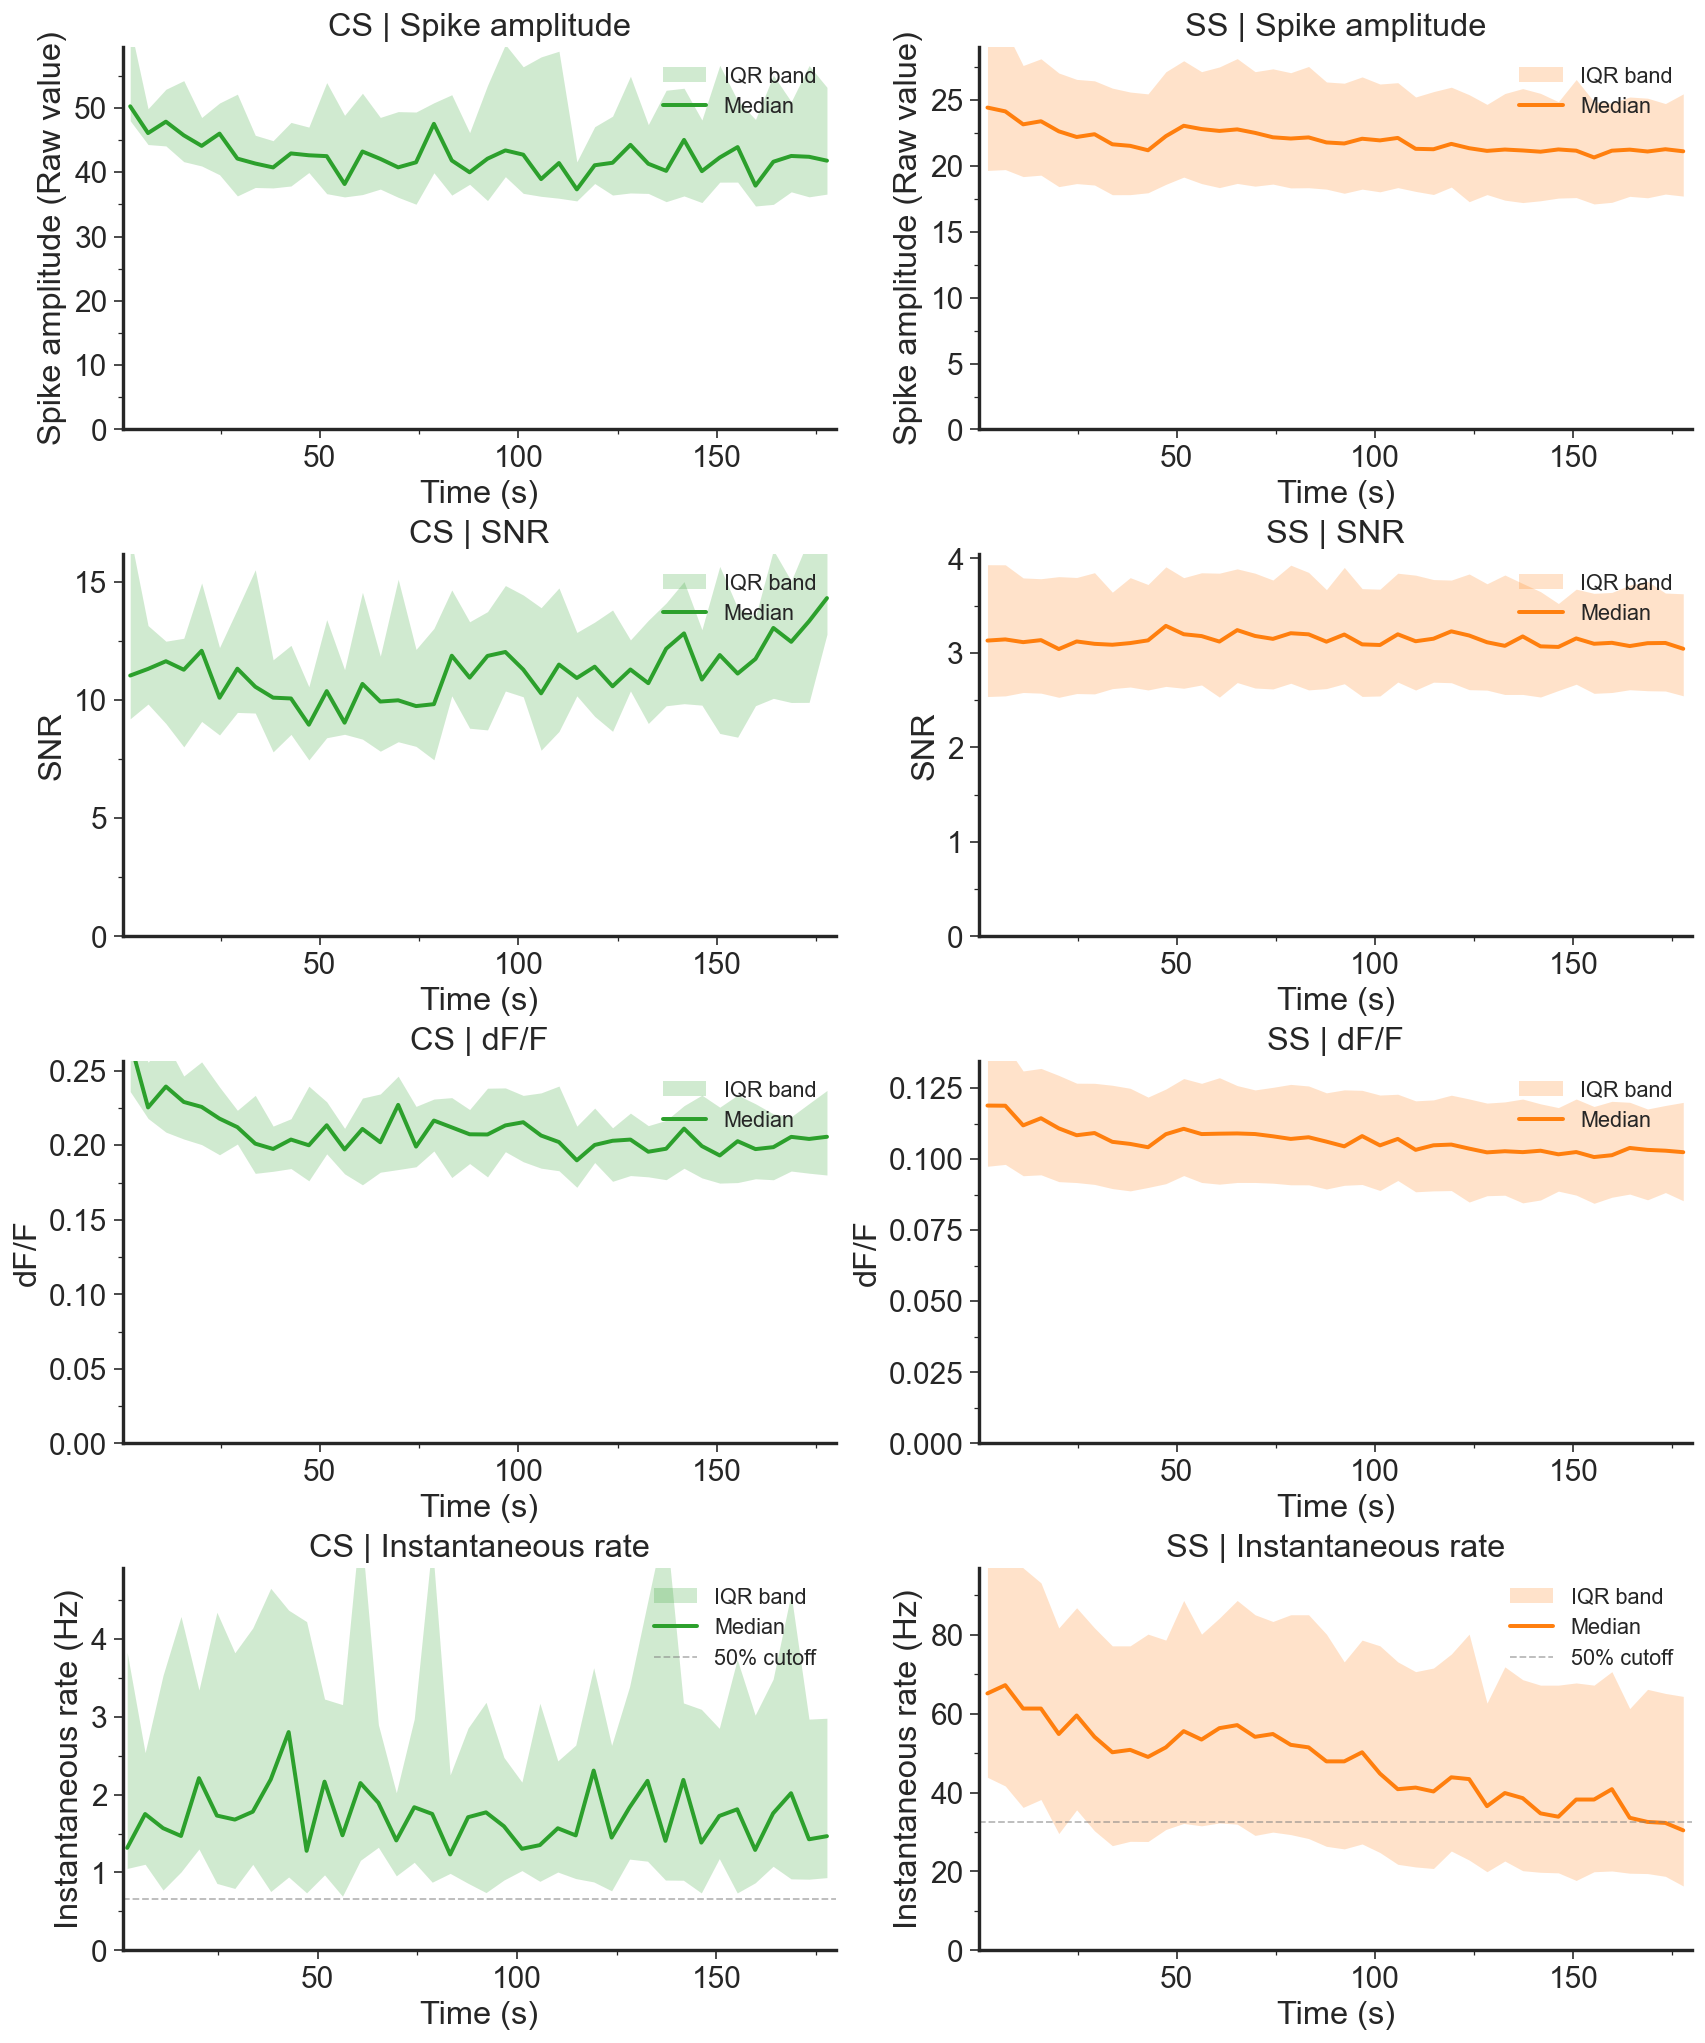

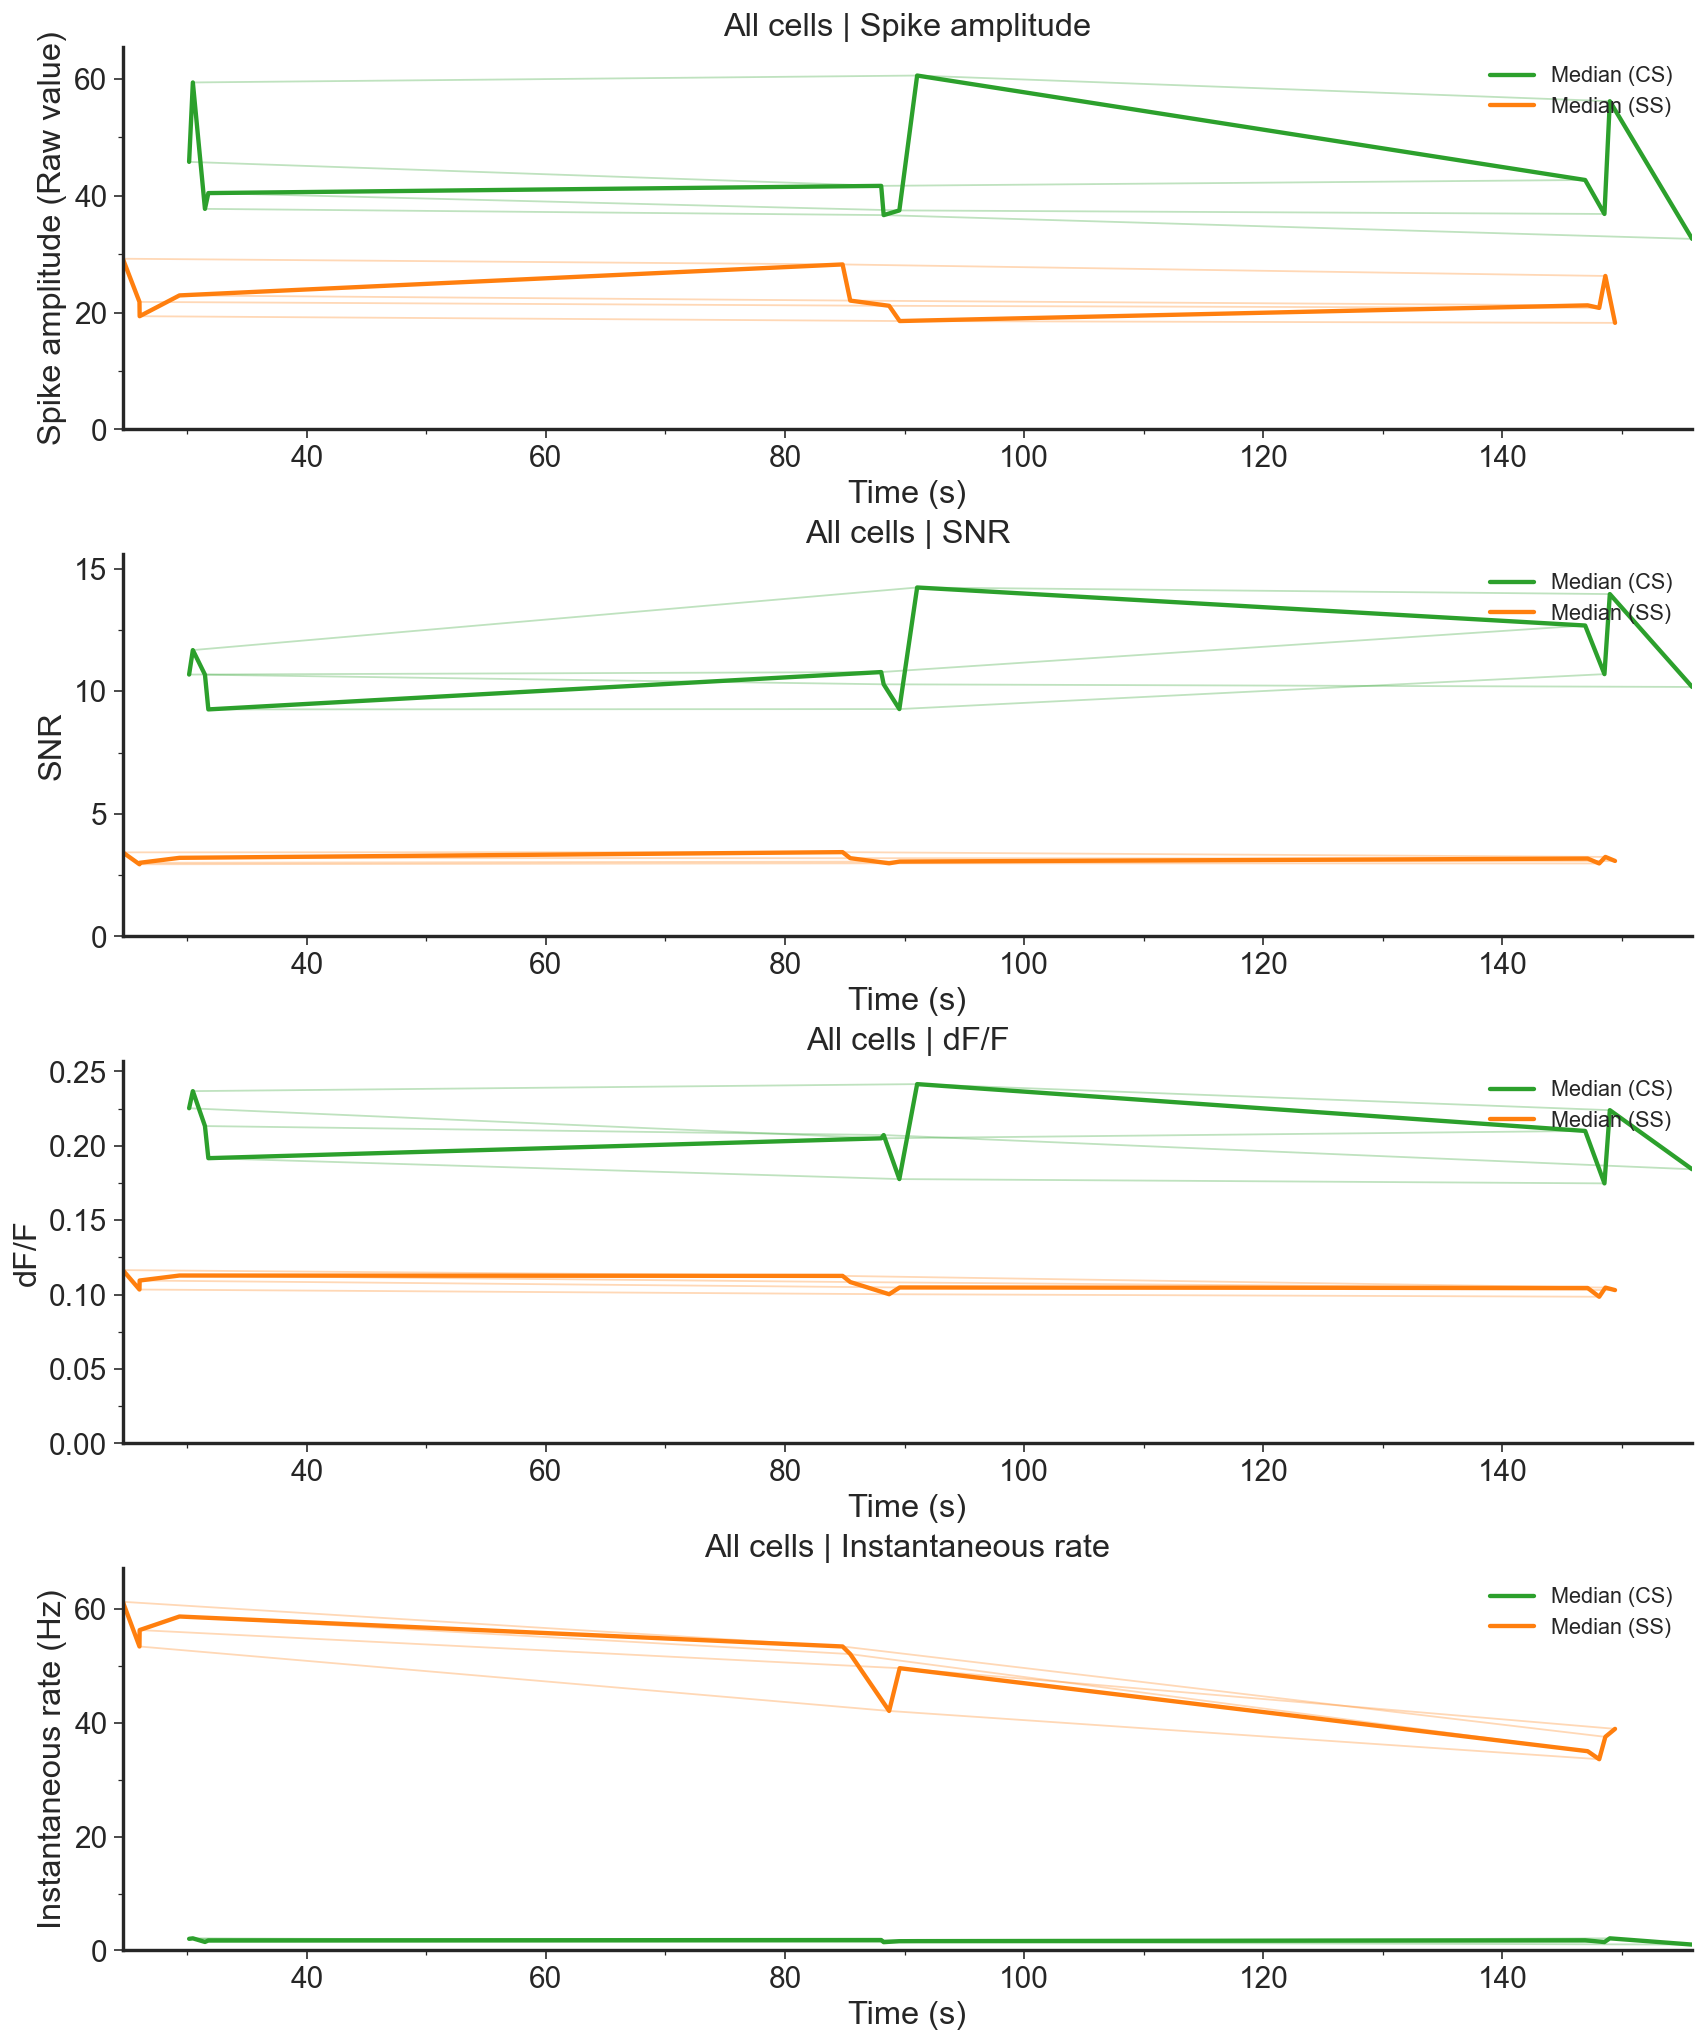

Per-cell 50% drop report (instantaneous firing rate):


,cell_idx,cell_name,spike_type,metric,initial_value,threshold_50pct,reached_50pct,drop_x,drop_label
0,0,avr (UG)(),CS,inst_rate_hz,2.124337,1.062168,False,NaN,None
1,0,avr (UG)(),SS,inst_rate_hz,61.274510,30.637255,False,NaN,None
2,1,avr (UG)(1),CS,inst_rate_hz,2.039489,1.019744,False,NaN,None
3,1,avr (UG)(1),SS,inst_rate_hz,58.685446,29.342723,False,NaN,None
4,2,avr (UG)(2),CS,inst_rate_hz,1.752915,0.876457,False,NaN,None
5,2,avr (UG)(2),SS,inst_rate_hz,53.418803,26.709402,False,NaN,None
6,3,avr (UG)(3),CS,inst_rate_hz,1.490102,0.745051,False,NaN,None
7,3,avr (UG)(3),SS,inst_rate_hz,56.306306,28.153153,False,NaN,None


No cells reached 50% drop under current settings.
Exported tables to: /Volumes/T7 Shield/20260518_A64_1PC_3min/bleaching_exports
Exported overview plots to: /Volumes/T7 Shield/20260518_A64_1PC_3min/bleaching_exports/plots


In [6]:
from pathlib import Path

def find_half_drop(df_one, metric):
    d = df_one[['x', metric, 'x_label']].dropna().sort_values('x')
    if d.empty:
        return None

    initial = float(d.iloc[0][metric])
    if not np.isfinite(initial):
        return None

    threshold = 0.5 * initial
    if initial == 0:
        return None

    crossed = d[d[metric] <= threshold]
    if crossed.empty:
        return {
            'initial_value': initial,
            'threshold_50pct': threshold,
            'drop_x': np.nan,
            'drop_label': None,
            'reached_50pct': False,
        }

    first = crossed.iloc[0]
    return {
        'initial_value': initial,
        'threshold_50pct': threshold,
        'drop_x': float(first['x']),
        'drop_label': str(first['x_label']),
        'reached_50pct': True,
    }

def metric_for_display(values, metric_name):
    arr = np.asarray(values, dtype=float)
    if NEGATIVE_GOING and DISPLAY_ABS_FOR_NEGATIVE and metric_name in ('amplitude_raw', 'snr', 'dff'):
        return np.abs(arr)
    return arr

def robust_ylim(y_arrays, q_low=0.05, q_high=0.95, pad_frac=0.15, force_non_negative=True):
    vals = []
    for y in y_arrays:
        yy = np.asarray(y, dtype=float)
        yy = yy[np.isfinite(yy)]
        if yy.size > 0:
            vals.append(yy)
    if len(vals) == 0:
        return None
    y = np.concatenate(vals)
    lo = float(np.quantile(y, q_low))
    hi = float(np.quantile(y, q_high))
    if not np.isfinite(lo) or not np.isfinite(hi):
        return None
    if hi <= lo:
        med = float(np.median(y))
        spread = float(np.std(y))
        spread = spread if np.isfinite(spread) and spread > 0 else max(abs(med) * 0.2, 1e-6)
        lo, hi = med - spread, med + spread
    pad = (hi - lo) * max(0.01, float(pad_frac))
    lo2, hi2 = lo - pad, hi + pad
    if force_non_negative:
        lo2 = max(0.0, lo2)
    if hi2 <= lo2:
        hi2 = lo2 + 1e-6
    return lo2, hi2

def compute_trend_and_band(x, y, full_t, mode='iqr', target_bins=40):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    v = np.isfinite(x) & np.isfinite(y)
    x, y = x[v], y[v]
    if x.size < 3:
        return np.array([]), np.array([]), np.array([]), np.array([])

    if not np.isfinite(full_t) or full_t <= 0:
        full_t = float(np.nanmax(x) - np.nanmin(x))
        if not np.isfinite(full_t) or full_t <= 0:
            return np.array([]), np.array([]), np.array([]), np.array([])

    n_bins = int(max(8, min(120, target_bins)))
    edges = np.linspace(0.0, full_t, n_bins + 1)
    b = np.digitize(x, edges) - 1

    rows = []
    for bi in range(n_bins):
        yy = y[b == bi]
        yy = yy[np.isfinite(yy)]
        if yy.size == 0:
            continue
        xc = 0.5 * (edges[bi] + edges[bi + 1])
        med = float(np.median(yy))
        if str(mode).lower() == 'sem':
            mu = float(np.mean(yy))
            sem = float(np.std(yy, ddof=1) / np.sqrt(max(1, yy.size))) if yy.size > 1 else 0.0
            lo, hi = mu - sem, mu + sem
            trend = mu
        else:
            q25 = float(np.quantile(yy, 0.25))
            q75 = float(np.quantile(yy, 0.75))
            lo, hi = q25, q75
            trend = med
        rows.append((xc, trend, lo, hi))

    if len(rows) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])
    arr = np.asarray(rows, dtype=float)
    return arr[:, 0], arr[:, 1], arr[:, 2], arr[:, 3]

def _safe_slug(text):
    return ''.join(ch if (ch.isalnum() or ch in ('_', '-')) else '_' for ch in str(text)).strip('_').lower()

def _set_independent_time_axis(ax, x_arrays, mode, sessions_local, fallback_full_t):
    if mode == 'session_as_datapoint':
        x = np.concatenate([np.asarray(v, dtype=float).ravel() for v in x_arrays if len(np.asarray(v)) > 0]) if x_arrays else np.array([])
        x = x[np.isfinite(x)]
        if x.size > 0:
            lo = float(np.min(x)) - 0.2
            hi = float(np.max(x)) + 0.2
            if hi <= lo:
                hi = lo + 1.0
            ax.set_xlim(lo, hi)
        elif len(sessions_local) > 0:
            ax.set_xlim(-0.2, len(sessions_local) - 0.8)
        ax.set_xlabel('Session index')
    else:
        x = np.concatenate([np.asarray(v, dtype=float).ravel() for v in x_arrays if len(np.asarray(v)) > 0]) if x_arrays else np.array([])
        x = x[np.isfinite(x)]
        if x.size > 0:
            lo = float(np.min(x))
            hi = float(np.max(x))
            if hi <= lo:
                hi = lo + 1.0
            ax.set_xlim(lo, hi)
        elif np.isfinite(fallback_full_t) and fallback_full_t > 0:
            ax.set_xlim(0.0, fallback_full_t)
        ax.set_xlabel('Time (s)')

# dF/F is kept for visualization but excluded from drop report per request.
REPORT_METRICS = ['inst_rate_hz']

# Unified switch for point cloud visibility.
DRAW_EVENT_POINTS = bool(DRAW_INDIVIDUAL_SPIKE_DOTS and PLOT_ALL_SPIKES)

SPIKE_COLORS = {'CS': 'tab:green', 'SS': 'tab:orange'}
LEGEND_FONTSIZE = max(1, int(round(9 * 1.3)))
PLOT_SAVE_DPI = max(150, int(FIG_DPI))
SAVE_PLOTS_SEPARATELY = bool(AUTO_SAVE_PLOTS)
PLOT_EXPORT_DIR = get_plot_export_dir()

# 1) Per-cell 50% drop report (instantaneous firing rate only)
report_rows = []
for (cell_idx, cell_name, spike_type), dsub in grouped.groupby(['cell_idx', 'cell_name', 'spike_type']):
    for m in REPORT_METRICS:
        out = find_half_drop(dsub, m)
        if out is None:
            continue
        report_rows.append({
            'cell_idx': int(cell_idx),
            'cell_name': str(cell_name),
            'spike_type': spike_type,
            'metric': m,
            **out,
        })

df_halfdrop = pd.DataFrame(report_rows)

# 2) Plot all spike events in separate rows (one row per metric)
spike_types_present = sorted(df_events['spike_type'].dropna().unique().tolist())
if len(spike_types_present) == 0:
    spike_types_present = ['SS', 'CS']

n_rows = len(METRICS)
n_cols = max(1, len(spike_types_present))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5 * n_cols, 3.9 * n_rows), constrained_layout=True, sharex=False)

if n_rows == 1 and n_cols == 1:
    axes = np.array([[axes]])
elif n_rows == 1:
    axes = np.array([axes])
elif n_cols == 1:
    axes = np.array(axes).reshape(n_rows, 1)

full_t = float(np.sum([s.get('duration_s', 0.0) for s in sessions]))
if ANALYSIS_MODE == 'first_session_only' and len(sessions) > 0:
    full_t = float(sessions[0].get('duration_s', full_t))

band_label = 'IQR band' if str(SHADE_MODE).lower() != 'sem' else 'SEM band (mean +/- SEM in each time bin)'
trend_label = 'Median' if str(SHADE_MODE).lower() != 'sem' else 'Mean'

panel_saves = []
for c, spike_type in enumerate(spike_types_present):
    d_ev = df_events[df_events['spike_type'] == spike_type].copy()
    spike_color = SPIKE_COLORS.get(str(spike_type).upper(), TREND_COLOR)

    for r, m in enumerate(METRICS):
        ax = axes[r, c]

        y_for_ylim = []
        x_for_xlim = []

        if not d_ev.empty:
            x_ev = d_ev['global_time_s'].to_numpy(dtype=float)
            y_ev = metric_for_display(d_ev[m].to_numpy(dtype=float), m)
            valid = np.isfinite(x_ev) & np.isfinite(y_ev)
            if np.any(valid):
                x_ok = x_ev[valid]
                y_ok = y_ev[valid]
                x_for_xlim.append(x_ok)

                if DRAW_EVENT_POINTS:
                    ax.scatter(
                        x_ok,
                        y_ok,
                        s=float(SCATTER_DOT_SIZE),
                        alpha=float(SCATTER_ALPHA),
                        color=spike_color,
                        edgecolors='none',
                        label='All spikes',
                        rasterized=True,
                    )
                    y_for_ylim.append(y_ok)

                xb, yb, ylo, yhi = compute_trend_and_band(
                    x=x_ok,
                    y=y_ok,
                    full_t=full_t,
                    mode=SHADE_MODE,
                    target_bins=TREND_TARGET_BINS,
                )
                if xb.size > 0:
                    x_for_xlim.append(xb)
                    ax.fill_between(xb, ylo, yhi, color=spike_color, alpha=float(BAND_ALPHA), linewidth=0, label=band_label)
                    ax.plot(xb, yb, color=spike_color, lw=float(TREND_LINE_WIDTH), label=trend_label)
                    y_for_ylim.extend([ylo, yhi, yb])

                    # For drop-threshold reference use trend start value.
                    if m in REPORT_METRICS and np.isfinite(yb[0]):
                        ax.axhline(0.5 * float(yb[0]), ls='--', lw=1, alpha=0.55, color='gray', label='50% cutoff')

        _set_independent_time_axis(ax, x_for_xlim, ANALYSIS_MODE, sessions, full_t)

        # Smart y scaling with robust quantiles and optional non-negative clamp.
        ylim = robust_ylim(
            y_for_ylim,
            q_low=float(Y_ROBUST_Q_LOW),
            q_high=float(Y_ROBUST_Q_HIGH),
            pad_frac=float(Y_PAD_FRAC),
            force_non_negative=True,
        )
        if ylim is not None:
            ax.set_ylim(*ylim)

        ax.set_title(f'{spike_type} | {metric_title(m)}')
        ax.set_ylabel(metric_ylabel(m))

        style_axis_ticks(ax)
        handles, labels = ax.get_legend_handles_labels()
        if len(labels) > 0:
            ax.legend(frameon=False, fontsize=LEGEND_FONTSIZE, loc='upper right')

        panel_saves.append((fig, ax, f'events_{_safe_slug(spike_type)}_{_safe_slug(m)}'))

if SAVE_PLOTS_SEPARATELY:
    saved_paths = [save_plot_figure(fig, 'events_overview')]
plt.show()

# 3) If multiple cells are loaded, plot per-cell trajectories in separate rows.
n_cells_loaded = int(grouped['cell_idx'].nunique())
if n_cells_loaded > 1:
    fig2, ax2 = plt.subplots(len(METRICS), 1, figsize=(13, 3.9 * len(METRICS)), constrained_layout=True, sharex=False)
    if len(METRICS) == 1:
        ax2 = np.array([ax2])

    panel_saves_2 = []
    for r, m in enumerate(METRICS):
        ax = ax2[r]
        y_for_ylim = []
        x_for_xlim = []

        for (cell_idx, cell_name, spike_type), d_cell in grouped.groupby(['cell_idx', 'cell_name', 'spike_type']):
            ds = d_cell[['x', m]].dropna().sort_values('x')
            if ds.empty:
                continue
            yv = metric_for_display(ds[m].to_numpy(dtype=float), m)
            xv = ds['x'].to_numpy(dtype=float)
            st_color = SPIKE_COLORS.get(str(spike_type).upper(), TREND_COLOR)
            ax.plot(xv, yv, lw=1.0, alpha=0.30, color=st_color)
            y_for_ylim.append(yv)
            x_for_xlim.append(xv)

        for st in spike_types_present:
            d_st = grouped[grouped['spike_type'] == st].copy()
            if d_st.empty:
                continue
            st_color = SPIKE_COLORS.get(str(st).upper(), TREND_COLOR)

            pooled = d_st.groupby('x', as_index=False)[m].median().sort_values('x')
            if not pooled.empty:
                y_pool = metric_for_display(pooled[m].to_numpy(dtype=float), m)
                x_pool = pooled['x'].to_numpy(dtype=float)
                ax.plot(x_pool, y_pool, color=st_color, lw=2.4, label=f'Median ({st})')
                y_for_ylim.append(y_pool)
                x_for_xlim.append(x_pool)

                # Add IQR/SEM band across cells at each x for each spike type.
                tmp = d_st[['x', m]].dropna().copy()
                if not tmp.empty:
                    stats_rows = []
                    for xv, dxx in tmp.groupby('x'):
                        yy = metric_for_display(dxx[m].to_numpy(dtype=float), m)
                        yy = yy[np.isfinite(yy)]
                        if yy.size == 0:
                            continue
                        if str(SHADE_MODE).lower() == 'sem':
                            mu = float(np.mean(yy))
                            sem = float(np.std(yy, ddof=1) / np.sqrt(max(1, yy.size))) if yy.size > 1 else 0.0
                            lo, hi, mid = mu - sem, mu + sem, mu
                        else:
                            lo = float(np.quantile(yy, 0.25))
                            hi = float(np.quantile(yy, 0.75))
                            mid = float(np.median(yy))
                        stats_rows.append((float(xv), mid, lo, hi))
                    if len(stats_rows) > 0:
                        arr = np.asarray(sorted(stats_rows, key=lambda z: z[0]), dtype=float)
                        ax.fill_between(arr[:, 0], arr[:, 2], arr[:, 3], color=st_color, alpha=float(BAND_ALPHA), linewidth=0)
                        y_for_ylim.extend([arr[:, 1], arr[:, 2], arr[:, 3]])
                        x_for_xlim.append(arr[:, 0])

        _set_independent_time_axis(ax, x_for_xlim, ANALYSIS_MODE, sessions, full_t)

        ylim = robust_ylim(
            y_for_ylim,
            q_low=float(Y_ROBUST_Q_LOW),
            q_high=float(Y_ROBUST_Q_HIGH),
            pad_frac=float(Y_PAD_FRAC),
            force_non_negative=True,
        )
        if ylim is not None:
            ax.set_ylim(*ylim)

        ax.set_title(f'All cells | {metric_title(m)}')
        ax.set_ylabel(metric_ylabel(m))

        style_axis_ticks(ax)
        handles, labels = ax.get_legend_handles_labels()
        if len(labels) > 0:
            ax.legend(frameon=False, fontsize=LEGEND_FONTSIZE, loc='upper right')

        panel_saves_2.append((fig2, ax, f'allcells_by_metric_{_safe_slug(m)}'))

    if SAVE_PLOTS_SEPARATELY:
        saved_paths_2 = [save_plot_figure(fig2, 'allcells_by_metric_overview')]
    plt.show()

# 4) Display report tables (no dF/F report)
if df_halfdrop.empty:
    print('No valid 50% drop report could be generated from current data/settings.')
else:
    cols = [
        'cell_idx', 'cell_name', 'spike_type', 'metric',
        'initial_value', 'threshold_50pct', 'reached_50pct', 'drop_x', 'drop_label'
    ]
    df_show = df_halfdrop[cols].sort_values(['cell_idx', 'spike_type', 'metric'])
    print('Per-cell 50% drop report (instantaneous firing rate):')
    display(df_show)

    reached = df_show[df_show['reached_50pct']].copy()
    if reached.empty:
        print('No cells reached 50% drop under current settings.')
    else:
        print('Cells/metrics that reached 50% drop:')
        display(reached)

# 5) Save outputs
output_dir = Path(DATA_FOLDER) / 'bleaching_exports'
output_dir.mkdir(parents=True, exist_ok=True)

df_events.to_csv(output_dir / 'bleaching_event_level_metrics.csv', index=False)
grouped.to_csv(output_dir / 'bleaching_aggregated_metrics.csv', index=False)
if not df_halfdrop.empty:
    df_halfdrop.to_csv(output_dir / 'bleaching_inst_rate_50pct_drop_report.csv', index=False)

print(f'Exported tables to: {output_dir}')
if SAVE_PLOTS_SEPARATELY:
    print(f'Exported overview plots to: {PLOT_EXPORT_DIR}')

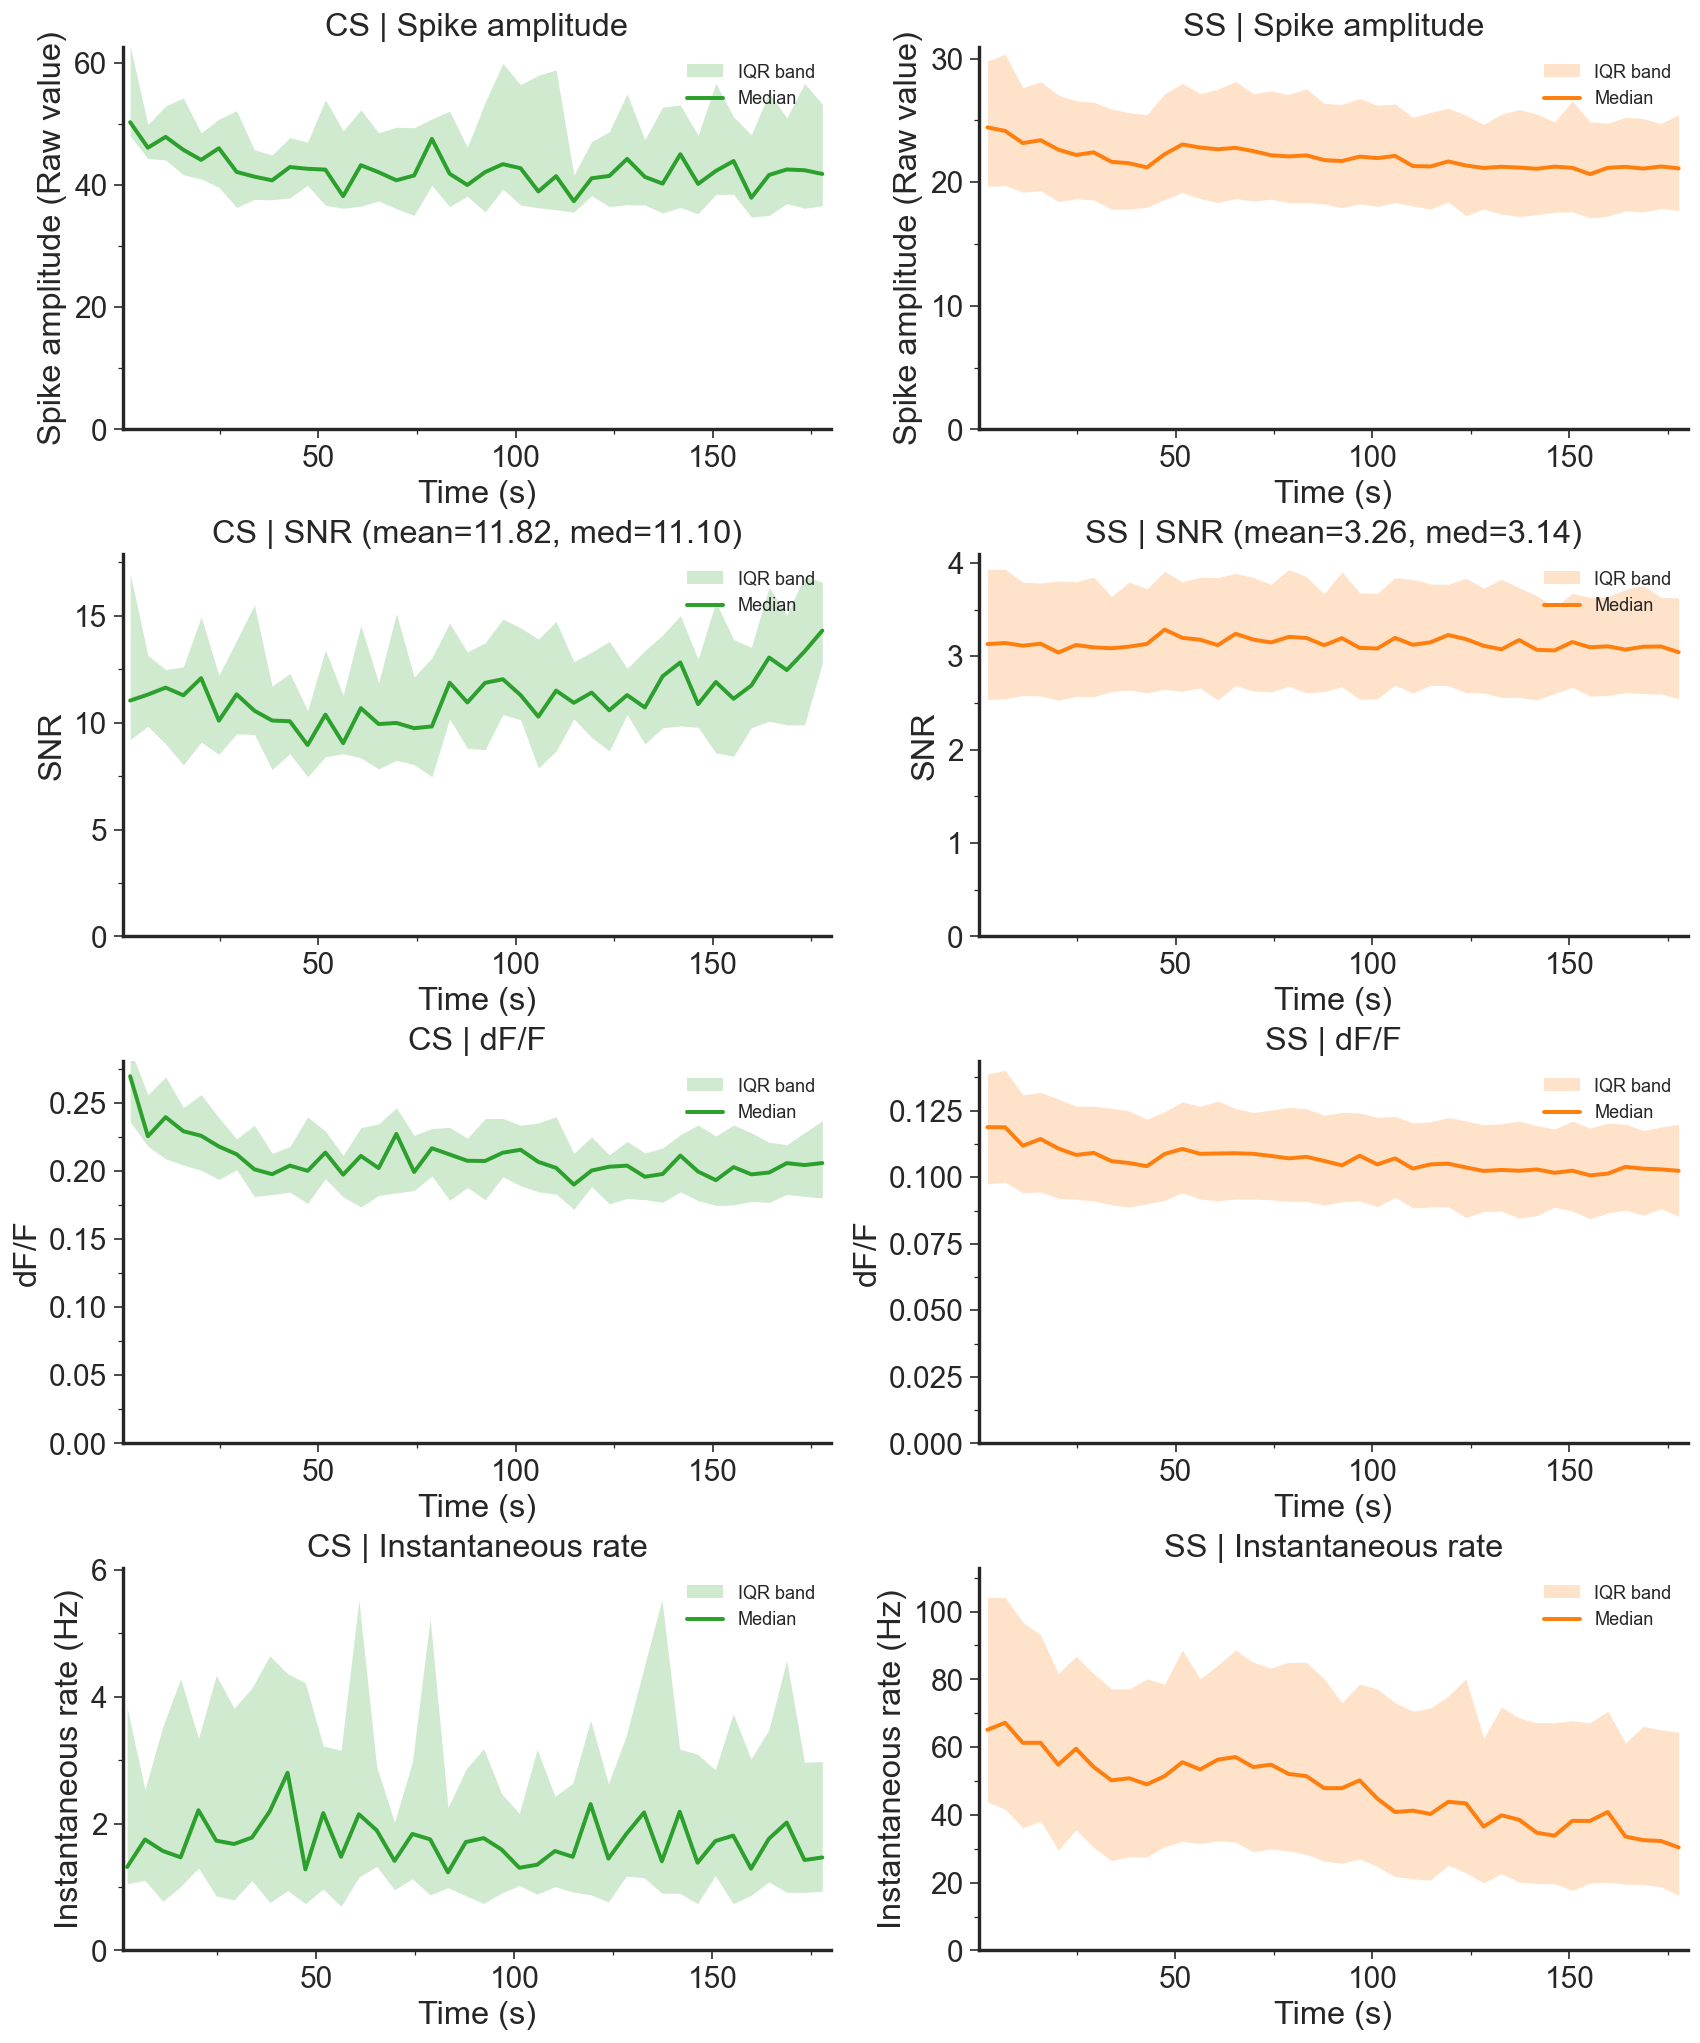

Replot finished with display winsorization.
Display-scaled overview plot exported to: /Volumes/T7 Shield/20260518_A64_1PC_3min/bleaching_exports/plots


In [7]:
# --- Corrected display scaling ---
# Run this after the main pipeline cell.

DISPLAY_Q_LOW = 0.01
DISPLAY_Q_HIGH = 0.99
DISPLAY_PAD_FRAC = 0.12
SHOW_SNR_REFERENCE = False

# Unified switch for point cloud visibility in this cell too.
DRAW_EVENT_POINTS = bool(DRAW_INDIVIDUAL_SPIKE_DOTS and PLOT_ALL_SPIKES)
SPIKE_COLORS = {'CS': 'tab:green', 'SS': 'tab:orange'}
LEGEND_FONTSIZE = max(1, int(round(8 * 1.3)))
PLOT_SAVE_DPI = max(150, int(FIG_DPI))
SAVE_PLOTS_SEPARATELY = bool(AUTO_SAVE_PLOTS)
PLOT_EXPORT_DIR = get_plot_export_dir()

def winsorize_for_display(y, q_low=0.01, q_high=0.99):
    yy = np.asarray(y, dtype=float).copy()
    finite = np.isfinite(yy)
    if finite.sum() < 5:
        return yy
    lo = float(np.quantile(yy[finite], q_low))
    hi = float(np.quantile(yy[finite], q_high))
    if np.isfinite(lo) and np.isfinite(hi) and hi > lo:
        yy[finite] = np.clip(yy[finite], lo, hi)
    return yy

def robust_ylim_display(y_arrays, q_low=0.01, q_high=0.99, pad_frac=0.12, force_non_negative=True):
    vals = []
    for y in y_arrays:
        yy = np.asarray(y, dtype=float)
        yy = yy[np.isfinite(yy)]
        if yy.size > 0:
            vals.append(yy)
    if len(vals) == 0:
        return None
    y = np.concatenate(vals)
    lo = float(np.quantile(y, q_low))
    hi = float(np.quantile(y, q_high))
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo = float(np.nanmin(y))
        hi = float(np.nanmax(y))
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return None
    pad = max(1e-6, (hi - lo) * float(pad_frac))
    lo2, hi2 = lo - pad, hi + pad
    if force_non_negative:
        lo2 = max(0.0, lo2)
    if hi2 <= lo2:
        hi2 = lo2 + 1e-6
    return lo2, hi2

def _safe_slug(text):
    return ''.join(ch if (ch.isalnum() or ch in ('_', '-')) else '_' for ch in str(text)).strip('_').lower()

def _set_independent_time_axis(ax, x_arrays, mode, sessions_local, fallback_full_t):
    if mode == 'session_as_datapoint':
        x = np.concatenate([np.asarray(v, dtype=float).ravel() for v in x_arrays if len(np.asarray(v)) > 0]) if x_arrays else np.array([])
        x = x[np.isfinite(x)]
        if x.size > 0:
            lo = float(np.min(x)) - 0.2
            hi = float(np.max(x)) + 0.2
            if hi <= lo:
                hi = lo + 1.0
            ax.set_xlim(lo, hi)
        elif len(sessions_local) > 0:
            ax.set_xlim(-0.2, len(sessions_local) - 0.8)
        ax.set_xlabel('Session index')
    else:
        x = np.concatenate([np.asarray(v, dtype=float).ravel() for v in x_arrays if len(np.asarray(v)) > 0]) if x_arrays else np.array([])
        x = x[np.isfinite(x)]
        if x.size > 0:
            lo = float(np.min(x))
            hi = float(np.max(x))
            if hi <= lo:
                hi = lo + 1.0
            ax.set_xlim(lo, hi)
        elif np.isfinite(fallback_full_t) and fallback_full_t > 0:
            ax.set_xlim(0.0, fallback_full_t)
        ax.set_xlabel('Time (s)')

# Re-plot all events with display winsorization to avoid weird Y axes


spike_types_present = sorted(df_events['spike_type'].dropna().unique().tolist())
if len(spike_types_present) == 0:
    spike_types_present = ['SS', 'CS']

METRICS_REPLOT = ['amplitude_raw', 'snr', 'dff', 'inst_rate_hz']
n_rows = len(METRICS_REPLOT)
n_cols = max(1, len(spike_types_present))
fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(6.5 * n_cols, 3.9 * n_rows), constrained_layout=True, sharex=False
)

if n_rows == 1 and n_cols == 1:
    axes = np.array([[axes]])
elif n_rows == 1:
    axes = np.array([axes])
elif n_cols == 1:
    axes = np.array(axes).reshape(n_rows, 1)

full_t = float(np.sum([s.get('duration_s', 0.0) for s in sessions]))
if ANALYSIS_MODE == 'first_session_only' and len(sessions) > 0:
    full_t = float(sessions[0].get('duration_s', full_t))

band_label = 'IQR band' if str(SHADE_MODE).lower() != 'sem' else 'SEM band (mean +/- SEM in each time bin)'
trend_label = 'Median' if str(SHADE_MODE).lower() != 'sem' else 'Mean'

panel_saves = []
for c, spike_type in enumerate(spike_types_present):
    d_ev = df_events[df_events['spike_type'] == spike_type].copy()
    spike_color = SPIKE_COLORS.get(str(spike_type).upper(), TREND_COLOR)

    for r, m in enumerate(METRICS_REPLOT):
        ax = axes[r, c]
        y_for_ylim = []
        x_for_xlim = []

        if not d_ev.empty:
            x_ev = d_ev['global_time_s'].to_numpy(dtype=float)
            y_ev_raw = metric_for_display(d_ev[m].to_numpy(dtype=float), m)
            valid = np.isfinite(x_ev) & np.isfinite(y_ev_raw)
            if np.any(valid):
                x_ok = x_ev[valid]
                y_ok = y_ev_raw[valid]
                y_plot = winsorize_for_display(y_ok, q_low=DISPLAY_Q_LOW, q_high=DISPLAY_Q_HIGH)
                x_for_xlim.append(x_ok)

                if DRAW_EVENT_POINTS:
                    ax.scatter(
                        x_ok, y_plot, s=float(SCATTER_DOT_SIZE), alpha=float(SCATTER_ALPHA),
                        color=spike_color, edgecolors='none', label='All spikes', rasterized=True
                    )
                    y_for_ylim.append(y_plot)

                xb, yb, ylo, yhi = compute_trend_and_band(
                    x=x_ok, y=y_plot, full_t=full_t, mode=SHADE_MODE, target_bins=TREND_TARGET_BINS
                )
                if xb.size > 0:
                    x_for_xlim.append(xb)
                    ax.fill_between(xb, ylo, yhi, color=spike_color, alpha=float(BAND_ALPHA), linewidth=0, label=band_label)
                    ax.plot(xb, yb, color=spike_color, lw=float(TREND_LINE_WIDTH), label=trend_label)
                    y_for_ylim.extend([yb, ylo, yhi])
        _set_independent_time_axis(ax, x_for_xlim, ANALYSIS_MODE, sessions, full_t)

        ylim = robust_ylim_display(
            y_for_ylim,
            q_low=float(DISPLAY_Q_LOW),
            q_high=float(DISPLAY_Q_HIGH),
            pad_frac=float(DISPLAY_PAD_FRAC),
            force_non_negative=True,
        )
        if ylim is not None:
            ax.set_ylim(*ylim)

        title = f'{spike_type} | {metric_title(m)}'
        if m == 'snr' and not d_ev.empty:
            y_s = metric_for_display(d_ev['snr'].to_numpy(dtype=float), 'snr')
            y_s = y_s[np.isfinite(y_s)]
            if y_s.size > 0:
                title += f' (mean={np.mean(y_s):.2f}, med={np.median(y_s):.2f})'
        ax.set_title(title)
        ax.set_ylabel(metric_ylabel(m))

        style_axis_ticks(ax)

        handles, labels = ax.get_legend_handles_labels()
        if len(labels) > 0:
            ax.legend(frameon=False, fontsize=LEGEND_FONTSIZE, loc='upper right')

        panel_saves.append((fig, ax, f'display_scaled_{_safe_slug(spike_type)}_{_safe_slug(m)}'))

plt.show()

print('Replot finished with display winsorization.')
if SAVE_PLOTS_SEPARATELY:
    print(f'Display-scaled overview plot exported to: {PLOT_EXPORT_DIR}')

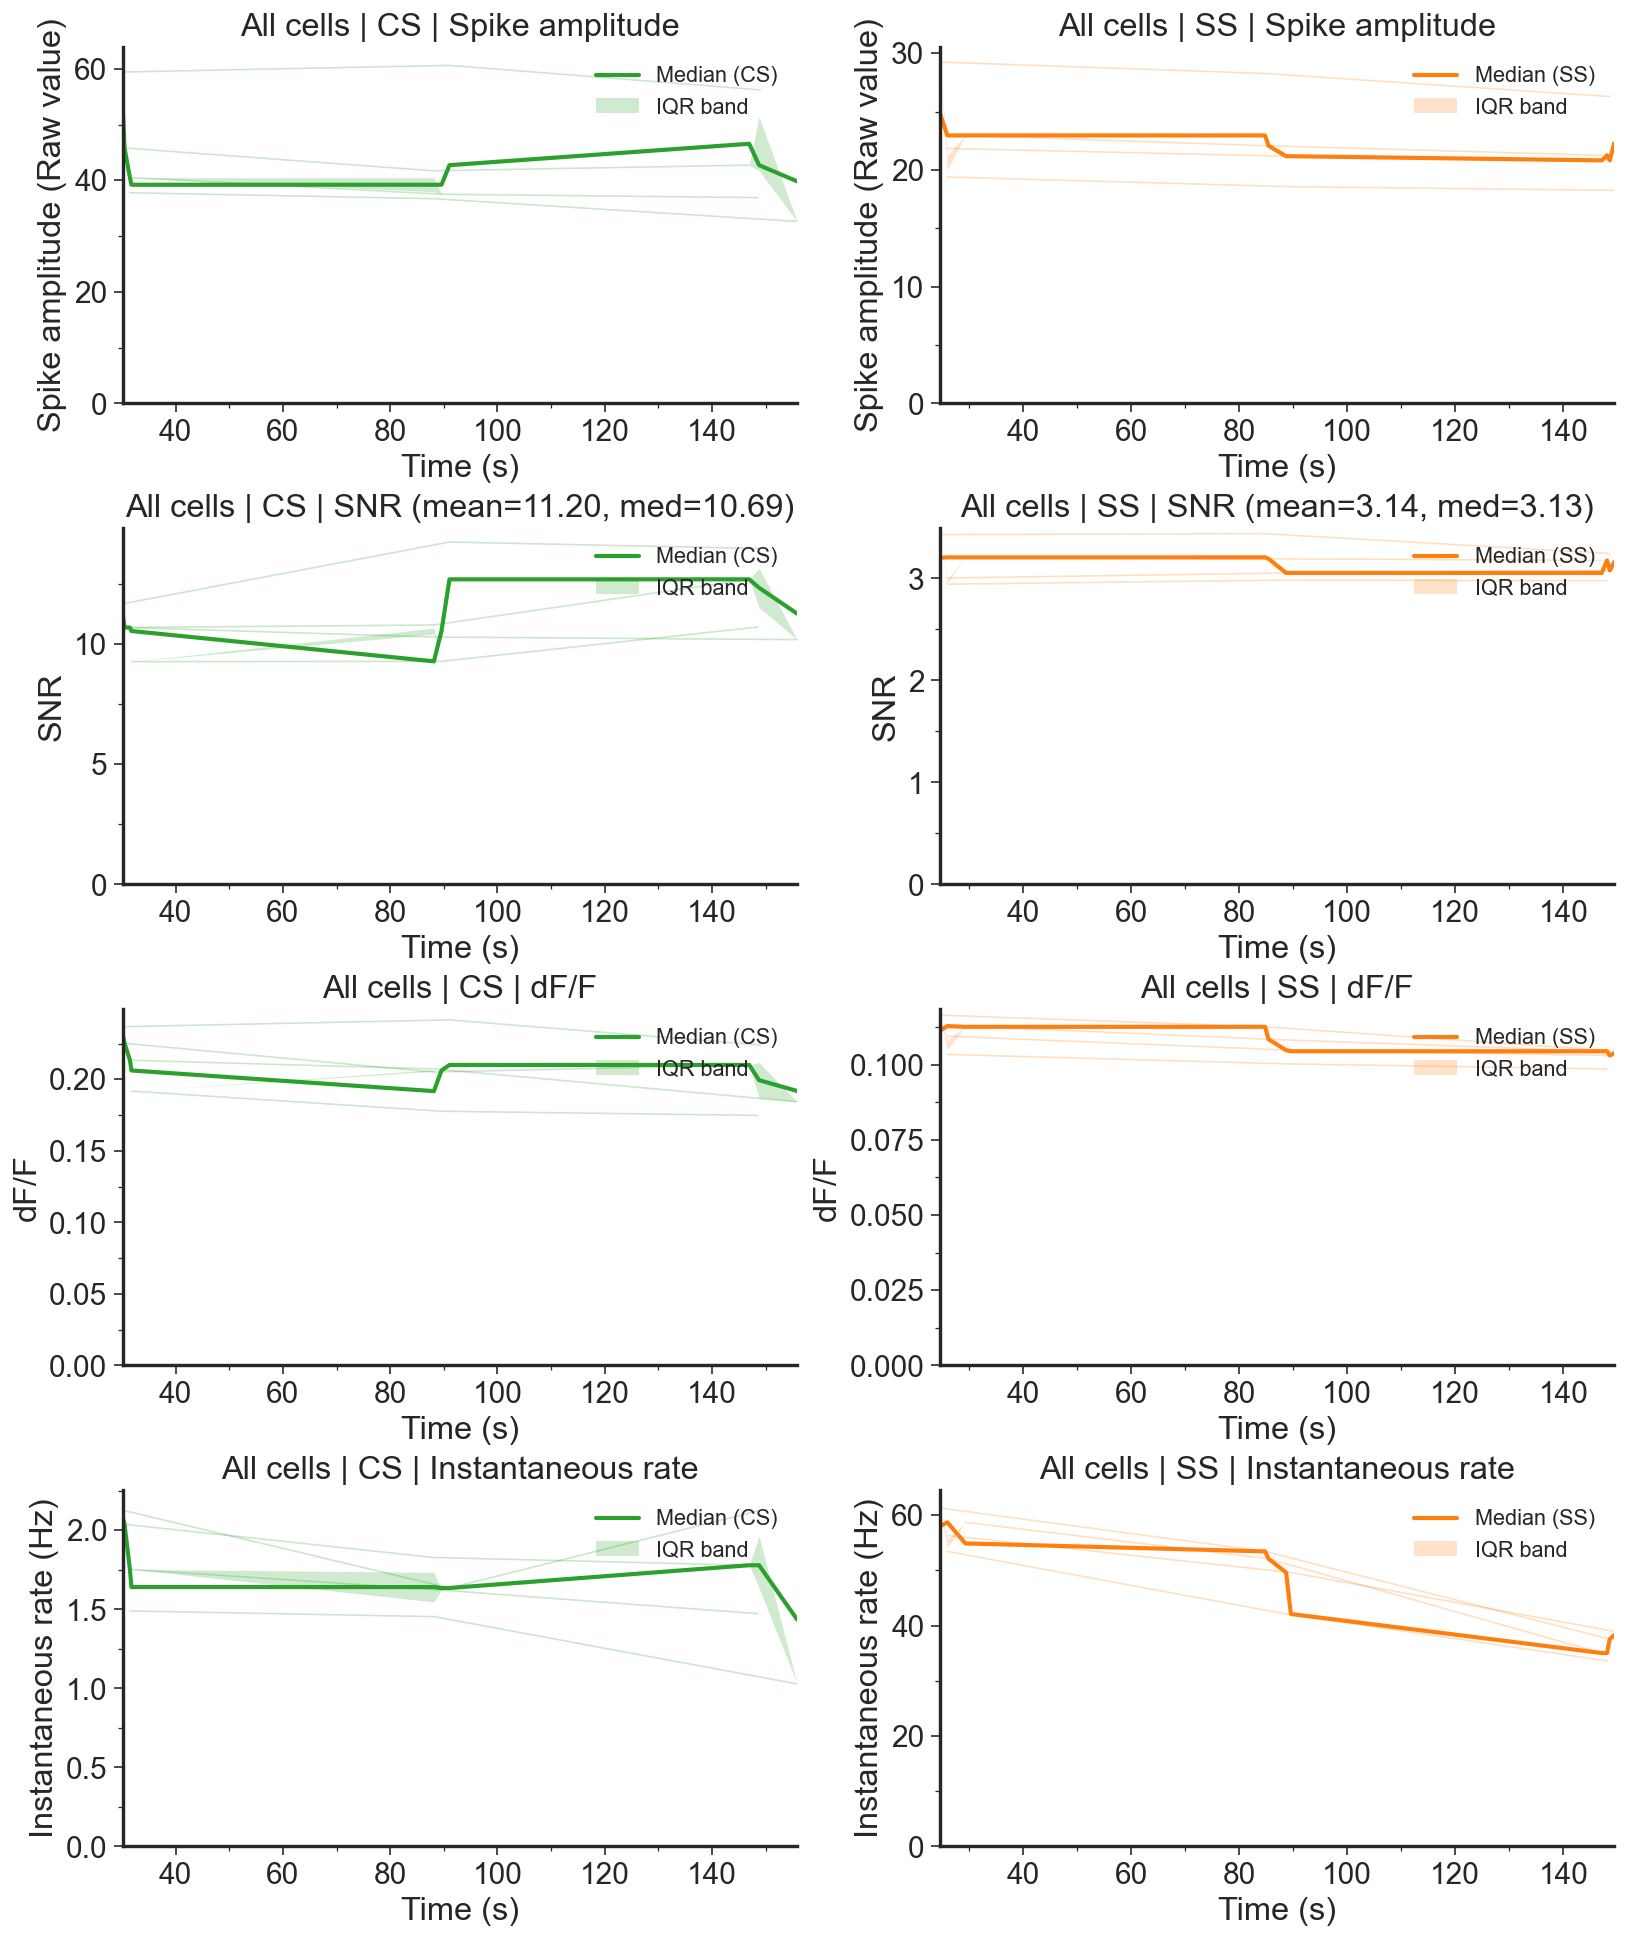

Corrected all-cells plot rendered (SS/CS separated, pooled line smoothed for display).
Corrected all-cells overview plot exported to: /Volumes/T7 Shield/20260518_A64_1PC_3min/bleaching_exports/plots


In [8]:
# --- Corrected all-cells summary plot (separate SS/CS pooling, stable bin centers) ---
if int(grouped['cell_idx'].nunique()) > 1:
    stypes = sorted(grouped['spike_type'].dropna().unique().tolist())
    if len(stypes) == 0:
        stypes = ['SS', 'CS']

    metrics_plot = ['amplitude_raw', 'snr', 'dff', 'inst_rate_hz']
    n_rows = len(metrics_plot)
    n_cols = len(stypes)
    ALLCELLS_SMOOTH_WINDOW = 3  # display-only smoothing for pooled black line

    SPIKE_COLORS = {'CS': 'tab:green', 'SS': 'tab:orange'}
    LEGEND_FONTSIZE = max(1, int(round(9 * 1.3)))
    PLOT_SAVE_DPI = max(150, int(FIG_DPI))
    SAVE_PLOTS_SEPARATELY = bool(AUTO_SAVE_PLOTS)
    PLOT_EXPORT_DIR = get_plot_export_dir()

    def _safe_slug(text):
        return ''.join(ch if (ch.isalnum() or ch in ('_', '-')) else '_' for ch in str(text)).strip('_').lower()

    fig_fix, ax_fix = plt.subplots(
        n_rows, n_cols, figsize=(6.2 * n_cols, 3.7 * n_rows),
        constrained_layout=True, sharex=False
    )

    if n_rows == 1 and n_cols == 1:
        ax_fix = np.array([[ax_fix]])
    elif n_rows == 1:
        ax_fix = np.array([ax_fix])
    elif n_cols == 1:
        ax_fix = np.array(ax_fix).reshape(n_rows, 1)

    def _collapse_by_xlabel(df_in, metric):
        d = df_in[['x', 'x_label', metric]].dropna().copy()
        if d.empty:
            return pd.DataFrame(columns=['x', metric])
        out = (
            d.groupby('x_label', as_index=False)
            .agg(x=('x', 'median'), y=(metric, 'median'))
            .sort_values('x')
            .rename(columns={'y': metric})
        )
        # De-duplicate almost-identical x centers using rounded bins to remove near-vertical artifacts.
        out['x_key'] = out['x'].round(2)
        out = (
            out.groupby('x_key', as_index=False)
            .agg(x=('x', 'median'), y=(metric, 'median'))
            .sort_values('x')
            .rename(columns={'y': metric})
        )
        return out

    def _collapse_band_rows(rows):
        if len(rows) == 0:
            return pd.DataFrame(columns=['x', 'lo', 'hi'])
        band_df = pd.DataFrame(rows, columns=['x', 'lo', 'hi'])
        band_df['x_key'] = band_df['x'].round(2)
        band_df = (
            band_df.groupby('x_key', as_index=False)
            .agg(x=('x', 'median'), lo=('lo', 'median'), hi=('hi', 'median'))
            .sort_values('x')
        )
        return band_df[['x', 'lo', 'hi']]

    def _smooth_display(y, window=3):
        arr = np.asarray(y, dtype=float)
        if arr.size < 3 or int(window) <= 1:
            return arr
        w = int(window)
        if w % 2 == 0:
            w += 1
        return pd.Series(arr).rolling(window=w, center=True, min_periods=1).median().to_numpy(dtype=float)

    panel_saves = []
    for c, st in enumerate(stypes):
        g_st = grouped[grouped['spike_type'] == st].copy()
        st_color = SPIKE_COLORS.get(str(st).upper(), TREND_COLOR)

        for r, m in enumerate(metrics_plot):
            ax = ax_fix[r, c]
            y_for_ylim = []
            x_for_xlim = []

            # Individual cell trajectories, collapsed per time/session label to avoid duplicate x artifacts.
            for (cell_idx, cell_name), d_cell in g_st.groupby(['cell_idx', 'cell_name']):
                ds = _collapse_by_xlabel(d_cell, m)
                if ds.empty:
                    continue
                xv = ds['x'].to_numpy(dtype=float)
                yv = metric_for_display(ds[m].to_numpy(dtype=float), m)
                yv = winsorize_for_display(yv, q_low=DISPLAY_Q_LOW, q_high=DISPLAY_Q_HIGH)
                ax.plot(xv, yv, lw=0.9, alpha=0.25, color=st_color)
                x_for_xlim.append(xv)
                y_for_ylim.append(yv)

            # Pooled median + spread within this spike type, also collapsed by label.
            pooled = _collapse_by_xlabel(g_st, m)
            if not pooled.empty:
                x_pool = pooled['x'].to_numpy(dtype=float)
                y_pool = metric_for_display(pooled[m].to_numpy(dtype=float), m)
                y_pool = winsorize_for_display(y_pool, q_low=DISPLAY_Q_LOW, q_high=DISPLAY_Q_HIGH)
                y_pool_smooth = _smooth_display(y_pool, window=ALLCELLS_SMOOTH_WINDOW)
                ax.plot(x_pool, y_pool_smooth, color=st_color, lw=2.3, label=f'Median ({st})')
                x_for_xlim.append(x_pool)
                y_for_ylim.append(y_pool_smooth)

                rows = []
                for xlab, dxx in g_st[['x', 'x_label', m]].dropna().groupby('x_label'):
                    x_center = float(np.median(dxx['x'].to_numpy(dtype=float)))
                    yy = metric_for_display(dxx[m].to_numpy(dtype=float), m)
                    yy = winsorize_for_display(yy, q_low=DISPLAY_Q_LOW, q_high=DISPLAY_Q_HIGH)
                    yy = yy[np.isfinite(yy)]
                    if yy.size == 0:
                        continue
                    if str(SHADE_MODE).lower() == 'sem':
                        mu = float(np.mean(yy))
                        sem = float(np.std(yy, ddof=1) / np.sqrt(max(1, yy.size))) if yy.size > 1 else 0.0
                        lo, hi = mu - sem, mu + sem
                    else:
                        lo = float(np.quantile(yy, 0.25))
                        hi = float(np.quantile(yy, 0.75))
                    rows.append((x_center, lo, hi))

                band_df = _collapse_band_rows(rows)
                if not band_df.empty:
                    ax.fill_between(
                        band_df['x'].to_numpy(),
                        band_df['lo'].to_numpy(),
                        band_df['hi'].to_numpy(),
                        color=st_color, alpha=float(BAND_ALPHA), linewidth=0, label='IQR band'
                    )
                    x_for_xlim.append(band_df['x'].to_numpy())
                    y_for_ylim.extend([band_df['lo'].to_numpy(), band_df['hi'].to_numpy()])

            if ANALYSIS_MODE == 'session_as_datapoint':
                ax.set_xlabel('Session index')
                if len(x_for_xlim) > 0:
                    xx = np.concatenate([np.asarray(v, dtype=float) for v in x_for_xlim])
                    xx = xx[np.isfinite(xx)]
                    if xx.size > 0:
                        ax.set_xlim(float(np.min(xx)) - 0.2, float(np.max(xx)) + 0.2)
                elif len(sessions) > 0:
                    ax.set_xlim(-0.2, len(sessions) - 0.8)
            else:
                ax.set_xlabel('Time (s)')
                if len(x_for_xlim) > 0:
                    xx = np.concatenate([np.asarray(v, dtype=float) for v in x_for_xlim])
                    xx = xx[np.isfinite(xx)]
                    if xx.size > 0:
                        lo_x = float(np.min(xx))
                        hi_x = float(np.max(xx))
                        if hi_x <= lo_x:
                            hi_x = lo_x + 1.0
                        ax.set_xlim(lo_x, hi_x)
                elif np.isfinite(full_t) and full_t > 0:
                    ax.set_xlim(0.0, full_t)

            ylim = robust_ylim_display(
                y_for_ylim, q_low=float(DISPLAY_Q_LOW), q_high=float(DISPLAY_Q_HIGH),
                pad_frac=float(DISPLAY_PAD_FRAC),
                force_non_negative=True,
            )
            if ylim is not None:
                ax.set_ylim(*ylim)

            ttl = f'All cells | {st} | {metric_title(m)}'
            if m == 'snr' and not g_st.empty:
                ys = metric_for_display(g_st[m].to_numpy(dtype=float), m)
                ys = ys[np.isfinite(ys)]
                if ys.size > 0:
                    ttl += f' (mean={np.mean(ys):.2f}, med={np.median(ys):.2f})'
            ax.set_title(ttl)
            ax.set_ylabel(metric_ylabel(m))

            style_axis_ticks(ax)

            handles, labels = ax.get_legend_handles_labels()
            if len(labels) > 0:
                ax.legend(frameon=False, fontsize=LEGEND_FONTSIZE, loc='upper right')

            panel_saves.append((fig_fix, ax, f'corrected_allcells_{_safe_slug(st)}_{_safe_slug(m)}'))

    if SAVE_PLOTS_SEPARATELY:
        saved_paths = [save_plot_figure(fig_fix, 'corrected_allcells_overview')]
    plt.show()

    print('Corrected all-cells plot rendered (SS/CS separated, pooled line smoothed for display).')
    if SAVE_PLOTS_SEPARATELY:
        print(f'Corrected all-cells overview plot exported to: {PLOT_EXPORT_DIR}')